# NB03 - Doppler image-audio QC integration

This notebook integrates the image-based Doppler quality-control pipeline from NB01 with the audio-based Doppler quality-control pipeline from NB02.

The goal is to test whether image-derived and audio-derived Doppler QC describe the same recording quality and identify similar usable Doppler segments.


The main exploratory recording is:

- `candidate_long_quality_test.avi`

This long recording is used first because it contains:

- a stable Doppler signal segment
- probe displacement
- signal degradation
- complete signal loss
- mechanical artifacts
- silence or near-silence

Additional longer candidate recordings will be used later for validation:

- `candidate_1.avi`
- `candidate_2.avi`
- `candidate_3.avi`

These recordings are expected to contain approximately 20-30 seconds of usable Doppler waveform with fewer major artifacts. They are intentionally kept for later validation after the integration workflow is stable on the exploratory long recording.

The initial focus of NB03 is segment-level agreement between image QC and audio QC.

Beat-level synchronization and feature fusion will be explored only after the segment-level pipeline is working.

## Imports and setup

In [1]:
import cv2, json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter, find_peaks, medfilt, hilbert, welch, spectrogram
import soundfile as sf
from scipy.ndimage import uniform_filter1d

In [2]:
RECORDINGS_DIR = Path(
    r"D:\code\DopplerLab\ultrasound_recordings"
)

new_candidate_paths = {
    "candidate_long_quality_test": RECORDINGS_DIR / "candidate_long_quality_test.avi",
    "new_candidate_avi_1": RECORDINGS_DIR / "candidate_1.avi",
    "new_candidate_avi_2": RECORDINGS_DIR / "candidate_2.avi",
    "new_candidate_avi_3": RECORDINGS_DIR / "candidate_3.avi",
}

for name, path in new_candidate_paths.items():
    print(name, path, path.exists())

candidate_long_quality_test D:\code\DopplerLab\ultrasound_recordings\candidate_long_quality_test.avi True
new_candidate_avi_1 D:\code\DopplerLab\ultrasound_recordings\candidate_1.avi True
new_candidate_avi_2 D:\code\DopplerLab\ultrasound_recordings\candidate_2.avi True
new_candidate_avi_3 D:\code\DopplerLab\ultrasound_recordings\candidate_3.avi True


In [3]:
LONG_VIDEO_PATH = new_candidate_paths["candidate_long_quality_test"]

## Imported functions from NB01 and NB02

This section collects stable functions from the previous notebooks.


### Image QC functions copied from NB01

The following image-based quality-control functions are used:

- `compute_frame_quality_metrics()`
- `apply_frame_quality_gate()`
- `run_image_quality_scan_for_video()`
- `summarize_frame_quality_segment()`
- `plot_image_quality_scan()`

### Audio QC functions copied from NB02

The following audio-based quality-control functions are used:

- `inspect_media_streams()`
- `extract_audio_to_wav()`
- `load_audio()`
- `compute_spectral_centroid()`
- `detect_audio_beats()`
- `build_audio_beat_table()`
- `apply_audio_qc()`
- `compute_band_energy()`
- `detect_usable_audio_segment()`
- `process_audio_recording_with_qc()`

### Integration strategy

The first integration step is to compare usable segments detected independently by image QC and audio QC.

The expected outputs are:

- image usable start and end time
- audio usable start and end time
- overlap duration
- union duration
- intersection-over-union agreement score
- start-time difference
- end-time difference
- common timeline plot

This allows image/audio agreement to be tested before more complex beat synchronization is attempted.

### Image QC functions

In [4]:
def extract_envelope_directional(mask, baseline, direction="auto", min_segment_length=5):
    """
    Extract Doppler envelope from a binary Doppler mask.

    Parameters
    ----------
    mask : np.ndarray
        Binary mask of Doppler signal inside ROI.

    baseline : int
        Row index of the Doppler baseline inside ROI.

    direction : str
        "above" -> Doppler spectrum is above baseline.
        "below" -> Doppler spectrum is below baseline.
        "auto"  -> side with stronger Doppler signal is selected automatically.

    min_segment_length : int
        Minimum vertical length of a continuous signal segment.
        Shorter segments are treated as noise.

    Returns
    -------
    envelope : np.ndarray
        Pixel row of the detected outer envelope for every x position.

    velocity : np.ndarray
        Distance from baseline to envelope, expressed in pixels.

    selected_direction : str
        Final selected direction: "above" or "below".
    """

    if direction not in ["auto", "above", "below"]:
        raise ValueError("direction must be 'auto', 'above', or 'below'")

    if baseline <= 0 or baseline >= mask.shape[0] - 1:
        raise ValueError("Baseline is outside valid ROI range.")

    if min_segment_length < 1:
        raise ValueError("min_segment_length must be >= 1.")

    above_area = int(mask[:baseline, :].sum())
    below_area = int(mask[baseline + 1:, :].sum())

    if direction == "auto":
        selected_direction = "above" if above_area >= below_area else "below"
    else:
        selected_direction = direction

    envelope = np.full(mask.shape[1], np.nan)

    for x in range(mask.shape[1]):

        if selected_direction == "above":
            ys = np.where(mask[:baseline, x])[0]

        else:
            ys_local = np.where(mask[baseline + 1:, x])[0]
            ys = baseline + 1 + ys_local

        if len(ys) == 0:
            continue

        breaks = np.where(np.diff(ys) > 1)[0] + 1
        segments = np.split(ys, breaks)

        valid_segments = [
            segment
            for segment in segments
            if len(segment) >= min_segment_length
        ]

        if len(valid_segments) == 0:
            continue

        if selected_direction == "above":
            envelope[x] = min(segment.min() for segment in valid_segments)

        else:
            envelope[x] = max(segment.max() for segment in valid_segments)

    if selected_direction == "above":
        velocity = baseline - envelope
    else:
        velocity = envelope - baseline

    return envelope, velocity, selected_direction

In [52]:
def extract_doppler_waveform(
    frame_rgb,
    x_min=80,
    x_max=640,
    y_min=230,
    y_max=510,
    threshold=80,
    direction="auto",
    min_segment_length=5,
    trim_left=10,
    trim_right=10,
    median_kernel_size=5,
    savgol_window_length=21,
    savgol_polyorder=3,
    peak_height=80,
    peak_distance=100,
):
    """
    Extract Doppler waveform from one ultrasound video frame.

    Returns a dictionary with local and global peak positions.
    """

    roi = frame_rgb[y_min:y_max, x_min:x_max]

    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold

    row_sums = mask.sum(axis=1)
    baseline = int(np.argmax(row_sums))

    envelope, velocity_raw, selected_direction = extract_envelope_directional(
        mask=mask,
        baseline=baseline,
        direction=direction,
        min_segment_length=min_segment_length,
    )

    if trim_left < 0 or trim_right < 0:
        raise ValueError("trim_left and trim_right must be non-negative.")

    if trim_left + trim_right >= len(envelope):
        raise ValueError("trim_left + trim_right is too large for signal length.")

    if trim_right == 0:
        keep_slice = slice(trim_left, None)
    else:
        keep_slice = slice(trim_left, -trim_right)

    envelope = envelope[keep_slice]
    velocity_raw = velocity_raw[keep_slice]

    x_offset = trim_left

    valid = np.where(~np.isnan(envelope))[0]

    if len(valid) == 0:
        raise ValueError(
            "No valid envelope points found. Check ROI, threshold, Doppler direction, min_segment_length, or trim settings."
        )

    envelope_interp = np.interp(
        np.arange(len(envelope)),
        valid,
        envelope[valid],
    )

    velocity_raw = np.interp(
        np.arange(len(velocity_raw)),
        valid,
        velocity_raw[valid],
    )

    if median_kernel_size % 2 == 0:
        median_kernel_size += 1

    velocity_med = medfilt(
        velocity_raw,
        kernel_size=median_kernel_size,
    )

    if savgol_window_length % 2 == 0:
        savgol_window_length += 1

    if savgol_window_length >= len(velocity_med):
        savgol_window_length = len(velocity_med) - 1

        if savgol_window_length % 2 == 0:
            savgol_window_length -= 1

    if savgol_window_length <= savgol_polyorder:
        raise ValueError(
            "savgol_window_length must be greater than savgol_polyorder."
        )

    velocity_smooth = savgol_filter(
        velocity_med,
        window_length=savgol_window_length,
        polyorder=savgol_polyorder,
    )

    peaks_local, peak_props = find_peaks(
        velocity_smooth,
        height=peak_height,
        distance=peak_distance,
    )

    peaks_global = peaks_local + x_offset

    return {
        "roi": roi,
        "gray": gray,
        "mask": mask,
        "baseline": baseline,
        "direction": selected_direction,
        "min_segment_length": min_segment_length,
        "trim_left": trim_left,
        "trim_right": trim_right,
        "x_offset": x_offset,
        "envelope": envelope_interp,
        "velocity_raw": velocity_raw,
        "velocity_med": velocity_med,
        "velocity_smooth": velocity_smooth,
        "peaks_local": peaks_local,
        "peaks_global": peaks_global,
        "peaks": peaks_local,
        "peak_props": peak_props,
    }

In [53]:
def plot_doppler_extraction_result(result, title="Doppler extraction result"):
    """
    Visual diagnostic plot for Doppler waveform extraction.

    Parameters
    ----------
    result : dict
        Output dictionary returned by extract_doppler_waveform().

    title : str
        Figure title.
    """

    roi = result["roi"]
    mask = result["mask"]

    baseline = result["baseline"]

    envelope = result["envelope"]

    velocity_smooth = result["velocity_smooth"]

    peaks = result["peaks"]

    direction = result["direction"]

    trim_left = result.get("trim_left", 0)
    x_offset = result.get("x_offset", 0)

    x_envelope = np.arange(len(envelope)) + x_offset

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 10),
    )

    # ROI

    axes[0].imshow(roi)

    axes[0].set_title(
        f"{title} | ROI | direction={direction}"
    )

    axes[0].axis("off")

    # MASK + ENVELOPE

    axes[1].imshow(
        mask,
        cmap="gray",
    )

    axes[1].plot(
        x_envelope,
        envelope,
        linewidth=2,
        label="envelope",
    )

    axes[1].axhline(
        baseline,
        linestyle="--",
        linewidth=2,
        label="baseline",
    )

    axes[1].set_title(
        "Mask with extracted envelope and baseline"
    )

    axes[1].set_ylabel(
        "ROI y [px]"
    )

    axes[1].legend()

    # VELOCITY

    x_velocity = np.arange(len(velocity_smooth))

    axes[2].plot(
        x_velocity,
        velocity_smooth,
        linewidth=2,
        label="velocity smooth",
    )

    axes[2].scatter(
        peaks,
        velocity_smooth[peaks],
        s=60,
        label="detected PSV peaks",
    )

    axes[2].set_title(
        f"Extracted Doppler velocity proxy (trim_left={trim_left})"
    )

    axes[2].set_xlabel(
        "ROI x [px]"
    )

    axes[2].set_ylabel(
        "Velocity proxy [px]"
    )

    axes[2].legend()

    plt.tight_layout()

    plt.show()

In [54]:
def analyze_beats(
    result,
    min_valley_distance_from_psv=10,
    secondary_peak_search_start_after_valley=5,
    secondary_peak_search_end_after_psv=70,
    min_time_to_valley_px=15,
    max_time_to_valley_fraction=0.65,
    require_secondary_peak=True,
):
    """
    Analyze Doppler beat morphology using output from extract_doppler_waveform().

    Beat quality is assessed using simple morphology rules.
    A beat is treated as complete when:
    - the first valley is not too early,
    - the first valley is not too late within the cycle,
    - secondary peak is present when required.

    Parameters
    ----------
    result : dict
        Output dictionary returned by extract_doppler_waveform().

    min_valley_distance_from_psv : int
        Minimum number of pixels after PSV before searching for first valley.

    secondary_peak_search_start_after_valley : int
        Number of pixels after first valley where secondary peak search starts.

    secondary_peak_search_end_after_psv : int
        End of secondary peak search window, counted from PSV position.

    min_time_to_valley_px : int
        Minimum accepted time from PSV to first valley.

    max_time_to_valley_fraction : float
        Maximum accepted fraction of cycle length before first valley.

    require_secondary_peak : bool
        If True, beats without secondary peak are marked as incomplete.

    Returns
    -------
    beat_df : pd.DataFrame
        Table with beat-level Doppler morphology features and quality flags.
    """

    velocity = result["velocity_smooth"]
    peaks_local = result["peaks_local"]
    peaks_global = result["peaks_global"]
    x_offset = result["x_offset"]

    rows = []

    for i in range(len(peaks_local) - 1):

        psv_local = int(peaks_local[i])
        next_psv_local = int(peaks_local[i + 1])

        psv_global = int(peaks_global[i])
        next_psv_global = int(peaks_global[i + 1])

        beat_start = psv_local
        beat_end = next_psv_local

        if beat_end <= beat_start:
            continue

        cycle_length_px = int(next_psv_local - psv_local)
        psv_value = float(velocity[psv_local])

        valley_search_start = beat_start + min_valley_distance_from_psv
        valley_search_end = beat_end

        if valley_search_start >= valley_search_end:
            continue

        valley_region = velocity[valley_search_start:valley_search_end]

        if len(valley_region) == 0:
            continue

        first_valley_local = int(
            valley_search_start + np.argmin(valley_region)
        )

        first_valley_global = int(first_valley_local + x_offset)
        first_valley_value = float(velocity[first_valley_local])

        time_to_valley_px = int(first_valley_local - psv_local)

        secondary_start = (
            first_valley_local + secondary_peak_search_start_after_valley
        )

        secondary_end = min(
            beat_start + secondary_peak_search_end_after_psv,
            beat_end,
        )

        if secondary_start < secondary_end:

            secondary_region = velocity[secondary_start:secondary_end]

            if len(secondary_region) > 0:
                secondary_peak_local = int(
                    secondary_start + np.argmax(secondary_region)
                )
                secondary_peak_global = int(secondary_peak_local + x_offset)
                secondary_peak_value = float(velocity[secondary_peak_local])
            else:
                secondary_peak_local = np.nan
                secondary_peak_global = np.nan
                secondary_peak_value = np.nan

        else:
            secondary_peak_local = np.nan
            secondary_peak_global = np.nan
            secondary_peak_value = np.nan

        if not np.isnan(secondary_peak_local):
            time_to_secondary_peak_px = int(secondary_peak_local - psv_local)
        else:
            time_to_secondary_peak_px = np.nan

        edv_proxy = first_valley_value

        ri_proxy = (
            (psv_value - edv_proxy) / psv_value
            if psv_value > 0
            else np.nan
        )

        valley_to_psv_ratio = (
            first_valley_value / psv_value
            if psv_value > 0
            else np.nan
        )

        secondary_to_psv_ratio = (
            secondary_peak_value / psv_value
            if psv_value > 0 and not np.isnan(secondary_peak_value)
            else np.nan
        )

        quality_reasons = []

        if time_to_valley_px < min_time_to_valley_px:
            quality_reasons.append("valley_too_early")

        if time_to_valley_px > cycle_length_px * max_time_to_valley_fraction:
            quality_reasons.append("valley_too_late")

        if require_secondary_peak and np.isnan(secondary_peak_local):
            quality_reasons.append("missing_secondary_peak")

        is_complete_beat = len(quality_reasons) == 0

        beat_quality_reason = (
            "ok"
            if is_complete_beat
            else ";".join(quality_reasons)
        )

        rows.append(
            {
                "beat_id": i + 1,

                "is_complete_beat": is_complete_beat,
                "beat_quality_reason": beat_quality_reason,

                "psv_local": psv_local,
                "psv_global": psv_global,
                "psv_value_px": psv_value,

                "next_psv_local": next_psv_local,
                "next_psv_global": next_psv_global,

                "first_valley_local": first_valley_local,
                "first_valley_global": first_valley_global,
                "first_valley_value_px": first_valley_value,

                "secondary_peak_local": secondary_peak_local,
                "secondary_peak_global": secondary_peak_global,
                "secondary_peak_value_px": secondary_peak_value,

                "cycle_length_px": cycle_length_px,
                "time_to_valley_px": time_to_valley_px,
                "time_to_secondary_peak_px": time_to_secondary_peak_px,

                "valley_to_psv_ratio": valley_to_psv_ratio,
                "secondary_to_psv_ratio": secondary_to_psv_ratio,
                "ri_proxy": ri_proxy,
            }
        )

    beat_df = pd.DataFrame(rows)

    return beat_df

In [55]:
def plot_beat_analysis(result, beat_df, title="Beat morphology analysis"):
    """
    Visualize PSV, first valley and secondary peak
    on extracted Doppler waveform.
    """

    velocity = result["velocity_smooth"]

    plt.figure(figsize=(14, 6))

    plt.plot(
        velocity,
        linewidth=2,
        label="velocity_smooth",
    )

    for _, row in beat_df.iterrows():

        # PSV

        plt.scatter(
            row["psv_local"],
            row["psv_value_px"],
            s=80,
            marker="o",
            label=None,
        )

        plt.text(
            row["psv_local"],
            row["psv_value_px"] + 3,
            f'PSV {int(row["beat_id"])}',
            fontsize=8,
        )

        # Valley

        plt.scatter(
            row["first_valley_local"],
            row["first_valley_value_px"],
            s=80,
            marker="v",
            label=None,
        )

        # Secondary peak

        if not pd.isna(row["secondary_peak_local"]):

            plt.scatter(
                row["secondary_peak_local"],
                row["secondary_peak_value_px"],
                s=80,
                marker="s",
                label=None,
            )

    plt.title(title)

    plt.xlabel("Signal position [px]")

    plt.ylabel("Velocity proxy [px]")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

In [5]:
def compute_frame_quality_metrics(
    frame_rgb,
    x_min=80,
    x_max=640,
    y_min=230,
    y_max=510,
    threshold=80,
    direction="auto",
    min_segment_length=5,
):
    """
    Compute image-quality metrics from a Doppler frame.

    Metrics are calculated from the Doppler spectrum side selected relative
    to the detected baseline. This avoids treating baseline/interface pixels
    as valid Doppler signal.

    Parameters
    ----------
    frame_rgb : np.ndarray
        Input RGB frame.

    x_min, x_max, y_min, y_max : int
        ROI coordinates.

    threshold : int
        Brightness threshold used to create Doppler mask.

    direction : str
        "above", "below", or "auto".

    min_segment_length : int
        Minimum vertical length of a continuous Doppler mask segment used
        during envelope extraction.

    Returns
    -------
    metrics : dict
        Image quality metrics.
    """

    roi = frame_rgb[
        y_min:y_max,
        x_min:x_max,
    ]

    gray = cv2.cvtColor(
        roi,
        cv2.COLOR_RGB2GRAY,
    )

    mask = gray > threshold

    row_sums = mask.sum(axis=1)
    baseline = int(np.argmax(row_sums))

    envelope, velocity_raw, selected_direction = extract_envelope_directional(
        mask=mask,
        baseline=baseline,
        direction=direction,
        min_segment_length=min_segment_length,
    )

    if selected_direction == "above":
        spectrum_mask = np.zeros_like(mask, dtype=bool)
        spectrum_mask[:baseline, :] = mask[:baseline, :]

    elif selected_direction == "below":
        spectrum_mask = np.zeros_like(mask, dtype=bool)
        spectrum_mask[baseline + 1:, :] = mask[baseline + 1:, :]

    else:
        raise ValueError("selected_direction must be 'above' or 'below'.")

    active_pixels = int(spectrum_mask.sum())
    total_pixels = int(spectrum_mask.size)

    active_pixel_fraction = (
        active_pixels / total_pixels
    )

    valid_envelope = ~np.isnan(envelope)

    envelope_coverage = (
        valid_envelope.mean()
    )

    if np.any(valid_envelope):
        valid_velocity = velocity_raw[valid_envelope]

        mean_velocity_px = float(
            np.nanmean(valid_velocity)
        )

        median_velocity_px = float(
            np.nanmedian(valid_velocity)
        )

        p95_velocity_px = float(
            np.nanpercentile(valid_velocity, 95)
        )

        envelope_area_px = float(
            np.nansum(valid_velocity)
        )

    else:
        mean_velocity_px = 0.0
        median_velocity_px = 0.0
        p95_velocity_px = 0.0
        envelope_area_px = 0.0

    mean_signal_intensity = (
        float(gray[spectrum_mask].mean())
        if active_pixels > 0
        else 0.0
    )

    metrics = {
        "baseline": baseline,
        "direction": selected_direction,
        "active_pixels": active_pixels,
        "active_pixel_fraction": active_pixel_fraction,
        "envelope_coverage": envelope_coverage,
        "mean_velocity_px": mean_velocity_px,
        "median_velocity_px": median_velocity_px,
        "p95_velocity_px": p95_velocity_px,
        "envelope_area_px": envelope_area_px,
        "mean_signal_intensity": mean_signal_intensity,
    }

    return metrics

In [6]:
def apply_frame_quality_gate(
    metrics,
    min_active_pixel_fraction=0.01,
    min_envelope_coverage=0.20,
    min_envelope_area_px=3000,
    min_p95_velocity_px=70,
):
    """
    Apply a simple rule-based image quality gate to one Doppler frame.

    Parameters
    ----------
    metrics : dict or pd.Series
        Output from compute_frame_quality_metrics().

    Returns
    -------
    qc_result : dict
        Quality-gate decision and reasons.
    """

    reasons = []

    if metrics["active_pixel_fraction"] < min_active_pixel_fraction:
        reasons.append("low_active_pixel_fraction")

    if metrics["envelope_coverage"] < min_envelope_coverage:
        reasons.append("low_envelope_coverage")

    if metrics["envelope_area_px"] < min_envelope_area_px:
        reasons.append("low_envelope_area")

    if metrics["p95_velocity_px"] < min_p95_velocity_px:
        reasons.append("low_p95_velocity")

    is_usable_frame = len(reasons) == 0

    if is_usable_frame:
        quality_reason = "ok"
    else:
        quality_reason = ";".join(reasons)

    qc_result = {
        "is_usable_frame": is_usable_frame,
        "frame_quality_reason": quality_reason,
    }

    return qc_result

In [7]:
def run_image_quality_scan_for_video(video_path, sample_step_s=0.5):
    """
    Run image quality metrics and frame-level QC
    across an entire Doppler recording.

    Parameters
    ----------
    video_path : str or Path
        Input video.

    sample_step_s : float
        Time interval between sampled frames.

    Returns
    -------
    quality_df : pd.DataFrame
        Frame-level image QC results.
    """

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(
            f"Cannot open video: {video_path}"
        )

    fps = cap.get(cv2.CAP_PROP_FPS)

    n_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    duration_s = n_frames / fps

    rows = []

    sample_times = np.arange(
        0,
        duration_s,
        sample_step_s,
    )

    for t in sample_times:

        frame_idx = int(
            round(t * fps)
        )

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            frame_idx,
        )

        ok, frame = cap.read()

        if not ok:
            continue

        frame_rgb = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB,
        )

        metrics = compute_frame_quality_metrics(
            frame_rgb=frame_rgb,
            direction="auto",
            min_segment_length=5,
        )

        qc = apply_frame_quality_gate(
            metrics
        )

        row = {}

        row["time_s"] = float(t)

        row.update(metrics)

        row.update(qc)

        rows.append(row)

    cap.release()

    quality_df = pd.DataFrame(rows)

    return quality_df

In [8]:
def summarize_frame_quality_segment(quality_scan_df):
    """
    Summarize usable Doppler segment from frame-level image QC results.

    Parameters
    ----------
    quality_scan_df : pd.DataFrame
        Output from run_image_quality_scan_for_video().

    Returns
    -------
    summary : dict
        Usable segment summary.
    """

    if len(quality_scan_df) == 0:
        raise ValueError("quality_scan_df is empty.")

    usable_df = quality_scan_df[
        quality_scan_df["is_usable_frame"]
    ].copy()

    total_duration_s = float(
        quality_scan_df["time_s"].max()
    )

    n_total_frames = int(
        len(quality_scan_df)
    )

    n_usable_frames = int(
        len(usable_df)
    )

    if n_usable_frames == 0:
        return {
            "image_usable_start_s": np.nan,
            "image_usable_end_s": np.nan,
            "image_usable_duration_s": 0.0,
            "image_usable_fraction": 0.0,
            "n_total_sampled_frames": n_total_frames,
            "n_usable_frames": 0,
            "total_duration_s": total_duration_s,
        }

    image_usable_start_s = float(
        usable_df["time_s"].min()
    )

    image_usable_end_s = float(
        usable_df["time_s"].max()
    )

    sample_step_s = float(
        np.median(np.diff(quality_scan_df["time_s"]))
    )

    image_usable_duration_s = float(
        n_usable_frames * sample_step_s
    )

    image_usable_fraction = float(
        image_usable_duration_s / total_duration_s
    )

    summary = {
        "image_usable_start_s": image_usable_start_s,
        "image_usable_end_s": image_usable_end_s,
        "image_usable_duration_s": image_usable_duration_s,
        "image_usable_fraction": image_usable_fraction,
        "n_total_sampled_frames": n_total_frames,
        "n_usable_frames": n_usable_frames,
        "total_duration_s": total_duration_s,
    }

    return summary

In [9]:
def plot_image_quality_scan(quality_scan_df):
    """
    Visualize image quality metrics across a long Doppler recording.
    """

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(14, 12),
        sharex=True,
    )

    time_s = quality_scan_df["time_s"]

    axes[0].plot(
        time_s,
        quality_scan_df["active_pixel_fraction"],
        linewidth=2,
    )

    axes[0].set_ylabel(
        "active_pixel_fraction"
    )

    axes[0].grid(alpha=0.3)

    axes[1].plot(
        time_s,
        quality_scan_df["envelope_coverage"],
        linewidth=2,
    )

    axes[1].set_ylabel(
        "envelope_coverage"
    )

    axes[1].grid(alpha=0.3)

    axes[2].plot(
        time_s,
        quality_scan_df["envelope_area_px"],
        linewidth=2,
    )

    axes[2].set_ylabel(
        "envelope_area_px"
    )

    axes[2].grid(alpha=0.3)

    usable = (
        quality_scan_df["is_usable_frame"]
        .astype(int)
    )

    axes[3].step(
        time_s,
        usable,
        where="mid",
        linewidth=2,
    )

    axes[3].set_ylabel(
        "usable"
    )

    axes[3].set_xlabel(
        "time [s]"
    )

    axes[3].set_ylim(
        -0.1,
        1.1,
    )

    axes[3].grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

### Audio QC functions

In [10]:
def inspect_media_streams(video_path):
    """
    Inspect video and audio streams using ffprobe.

    Parameters
    ----------
    video_path : str or Path

    Returns
    -------
    dict
        Parsed ffprobe metadata.
    """

    cmd = [
        "ffprobe",
        "-v",
        "quiet",
        "-print_format",
        "json",
        "-show_format",
        "-show_streams",
        str(video_path),
    ]

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        check=True,
    )

    metadata = json.loads(result.stdout)

    print("=" * 80)
    print(video_path)
    print("=" * 80)

    streams = metadata.get("streams", [])

    for stream in streams:

        codec_type = stream.get("codec_type")

        print()
        print(f"Stream type: {codec_type}")

        if codec_type == "audio":

            print(
                f"Codec: {stream.get('codec_name')}"
            )

            print(
                f"Sample rate: {stream.get('sample_rate')}"
            )

            print(
                f"Channels: {stream.get('channels')}"
            )

            print(
                f"Duration: {stream.get('duration')}"
            )

        elif codec_type == "video":

            print(
                f"Codec: {stream.get('codec_name')}"
            )

            print(
                f"Resolution: "
                f"{stream.get('width')} x {stream.get('height')}"
            )

            print(
                f"FPS: {stream.get('r_frame_rate')}"
            )

    return metadata

In [11]:
def extract_audio_to_wav(
    video_path,
    output_dir,
    output_name=None,
    sample_rate=None,
    mono=True,
    overwrite=True,
):
    """
    Extract the audio stream from an AVI file into a WAV file.

    Parameters
    ----------
    video_path : str or Path
        Path to the input video file.

    output_dir : str or Path
        Directory where the extracted WAV file will be saved.

    output_name : str or None
        Optional custom output WAV filename.

    sample_rate : int or None
        Optional target sample rate.
        If None, the original sample rate is preserved.

    mono : bool
        If True, audio is converted to mono.

    overwrite : bool
        If True, existing output file is overwritten.

    Returns
    -------
    Path
        Path to the extracted WAV file.
    """

    video_path = Path(video_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if output_name is None:
        output_name = video_path.stem + "_audio.wav"

    output_path = output_dir / output_name

    cmd = ["ffmpeg"]

    if overwrite:
        cmd.append("-y")
    else:
        cmd.append("-n")

    cmd.extend(
        [
            "-i",
            str(video_path),
            "-vn",
            "-acodec",
            "pcm_s16le",
        ]
    )

    if mono:
        cmd.extend(["-ac", "1"])

    if sample_rate is not None:
        cmd.extend(["-ar", str(sample_rate)])

    cmd.append(str(output_path))

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("Audio extraction failed.")

    print(f"Extracted audio:")
    print(f"  input:  {video_path}")
    print(f"  output: {output_path}")

    return output_path

In [12]:
def load_audio(audio_path):
    """
    Load WAV audio file.

    Parameters
    ----------
    audio_path : str or Path

    Returns
    -------
    dict
        Audio information and waveform.
    """

    signal, sample_rate = sf.read(audio_path)

    duration_s = len(signal) / sample_rate

    info = {
        "signal": signal.astype(np.float64),
        "sample_rate": sample_rate,
        "duration_s": duration_s,
        "n_samples": len(signal),
    }

    print("=" * 80)
    print(audio_path)
    print("=" * 80)

    print(f"Sample rate : {sample_rate:,} Hz")
    print(f"Duration : {duration_s:.3f} s")
    print(f"Samples : {len(signal):,}")

    print()
    print(f"Min value : {signal.min():.4f}")
    print(f"Max value : {signal.max():.4f}")
    print(f"Mean : {signal.mean():.6f}")
    print(f"Std : {signal.std():.6f}")

    return info

In [13]:
def compute_spectral_centroid(freqs, times, Sxx, fmin=100, fmax=3000, smooth_points=15):
    """
    Compute spectrogram spectral centroid.

    Parameters
    ----------
    freqs : ndarray
        Spectrogram frequency bins.

    times : ndarray
        Spectrogram time bins.

    Sxx : ndarray
        Spectrogram power matrix [freqs, times].

    fmin : float
        Lower frequency bound.

    fmax : float
        Upper frequency bound.

    smooth_points : int
        Smoothing window length.

    Returns
    -------
    times : ndarray
        Spectrogram time bins.

    centroid : ndarray
        Spectral centroid trajectory [Hz].
    """

    freqs = np.asarray(freqs)
    times = np.asarray(times)
    Sxx = np.asarray(Sxx)

    mask = (freqs >= fmin) & (freqs <= fmax)

    band_freqs = freqs[mask]
    band_power = Sxx[mask]

    numerator = np.sum(
        band_freqs[:, None] * band_power,
        axis=0,
    )

    denominator = np.sum(
        band_power,
        axis=0,
    )

    centroid = numerator / (denominator + 1e-12)

    if smooth_points is not None and smooth_points >= 5:

        if smooth_points % 2 == 0:
            smooth_points += 1

        if smooth_points < len(centroid):

            centroid = savgol_filter(
                centroid,
                window_length=smooth_points,
                polyorder=2,
            )

    return times, centroid

In [14]:
def detect_audio_beats(times, centroid, min_distance_s=0.5, prominence=100):
    """
    Detect candidate cardiac beats from spectral centroid.

    Parameters
    ----------
    times : ndarray

    centroid : ndarray

    min_distance_s : float
        Minimum spacing between beats.

    prominence : float
        Peak prominence threshold.

    Returns
    -------
    peak_idx : ndarray
    peak_times : ndarray
    peak_values : ndarray
    """

    dt = np.median(np.diff(times))

    distance = max(
        1,
        int(min_distance_s / dt),
    )

    peak_idx, props = find_peaks(
        centroid,
        distance=distance,
        prominence=prominence,
    )

    peak_times = times[peak_idx]
    peak_values = centroid[peak_idx]

    print(f"Detected beats: {len(peak_idx)}")

    if len(peak_times) > 1:

        rr = np.diff(peak_times)

        print(
            f"Mean RR: {rr.mean():.3f} s"
        )

        print(
            f"Estimated HR: {60 / rr.mean():.1f} bpm"
        )

    return peak_idx, peak_times, peak_values

In [15]:
def build_audio_beat_table(peak_times, peak_values):
    """
    Build beat-level audio feature table.

    Parameters
    ----------
    peak_times : ndarray
    peak_values : ndarray

    Returns
    -------
    pd.DataFrame
    """

    peak_times = np.asarray(peak_times)
    peak_values = np.asarray(peak_values)

    rows = []

    for i in range(len(peak_times)):

        row = {}

        row["beat_id"] = i + 1
        row["beat_time_s"] = peak_times[i]
        row["peak_centroid_hz"] = peak_values[i]

        if i > 0:
            row["rr_interval_s"] = (
                peak_times[i] - peak_times[i - 1]
            )
        else:
            row["rr_interval_s"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)

In [16]:
def apply_audio_qc(beat_df, centroid_fraction=0.60):
    """
    Apply simple audio quality control.

    Parameters
    ----------
    beat_df : pd.DataFrame

    centroid_fraction : float
        Fraction of median centroid required
        to be considered a valid beat.

    Returns
    -------
    pd.DataFrame
    """

    beat_df = beat_df.copy()

    median_centroid = np.median(
        beat_df["peak_centroid_hz"]
    )

    threshold = (
        centroid_fraction
        * median_centroid
    )

    beat_df["median_centroid_hz"] = median_centroid

    beat_df["qc_threshold_hz"] = threshold

    beat_df["is_valid"] = (
        beat_df["peak_centroid_hz"]
        >= threshold
    )

    return beat_df

In [17]:
def compute_band_energy(
    signal,
    sample_rate,
    fmin=100,
    fmax=2000,
    smooth_points=25,
    normalize=True,
    lower_percentile=5,
    upper_percentile=95,
):
    """
    Compute robust spectrogram band energy over time.

    This version uses percentile-based normalization instead of max normalization.
    That makes the signal less sensitive to isolated mechanical artifacts,
    such as probe bumps or sudden contact noise.

    Parameters
    ----------
    signal : np.ndarray
        Audio waveform.

    sample_rate : int
        Audio sample rate in Hz.

    fmin : float
        Lower frequency bound.

    fmax : float
        Upper frequency bound.

    smooth_points : int
        Smoothing window in spectrogram time bins.

    normalize : bool
        If True, robust percentile normalization is applied.

    lower_percentile : float
        Lower percentile used as robust baseline.

    upper_percentile : float
        Upper percentile used as robust high-energy reference.

    Returns
    -------
    times : np.ndarray
        Spectrogram time bins.

    band_energy : np.ndarray
        Band-limited Doppler energy signal.
    """

    freqs, times, Sxx = spectrogram(
        signal,
        fs=sample_rate,
        nperseg=2048,
        noverlap=1536,
        scaling="density",
    )

    freq_mask = (
        (freqs >= fmin)
        &
        (freqs <= fmax)
    )

    band_energy = np.sum(
        Sxx[freq_mask],
        axis=0,
    )

    band_energy = np.asarray(
        band_energy,
        dtype=np.float64,
    )

    if smooth_points is not None and smooth_points > 1:

        band_energy = uniform_filter1d(
            band_energy,
            size=smooth_points,
        )

    if normalize:

        low = np.percentile(
            band_energy,
            lower_percentile,
        )

        high = np.percentile(
            band_energy,
            upper_percentile,
        )

        if high > low:

            band_energy = (
                (band_energy - low)
                / (high - low)
            )

            band_energy = np.clip(
                band_energy,
                0,
                1,
            )

    return times, band_energy

In [18]:
def detect_usable_audio_segment(times, band_energy, energy_threshold=0.20):
    """
    Detect usable Doppler audio segment using band energy.

    Parameters
    ----------
    times : np.ndarray
        Time axis.

    band_energy : np.ndarray
        Normalized band energy.

    energy_threshold : float
        Minimum energy required to be considered usable.

    Returns
    -------
    dict
    """

    mask = band_energy >= energy_threshold

    if not np.any(mask):

        return {
            "usable_start_s": np.nan,
            "usable_end_s": np.nan,
            "usable_duration_s": 0.0,
            "usable_fraction": 0.0,
            "energy_threshold": energy_threshold,
        }

    usable_idx = np.where(mask)[0]

    start_idx = usable_idx[0]
    end_idx = usable_idx[-1]

    usable_start_s = float(times[start_idx])
    usable_end_s = float(times[end_idx])

    usable_duration_s = (
        usable_end_s
        - usable_start_s
    )

    recording_duration_s = float(times[-1])

    usable_fraction = (
        usable_duration_s
        / recording_duration_s
    )

    return {
        "usable_start_s": usable_start_s,
        "usable_end_s": usable_end_s,
        "usable_duration_s": usable_duration_s,
        "usable_fraction": usable_fraction,
        "energy_threshold": energy_threshold,
    }

In [19]:
def process_audio_recording_with_qc(
    audio_path,
    centroid_fmin=100,
    centroid_fmax=3000,
    centroid_smooth_points=15,
    min_distance_s=0.5,
    prominence=100,
    qc_centroid_fraction=0.80,
    energy_fmin=100,
    energy_fmax=2000,
    energy_smooth_points=25,
    energy_threshold=0.20,
):
    """
    Complete Doppler audio processing pipeline with two-level QC.

    This function processes one Doppler audio recording and applies:

    1. Beat-level QC based on spectral centroid.
    2. Segment-level QC based on robust spectrogram band energy.

    RR and HR summary metrics are computed only from consecutive
    final-valid beats. This prevents artificial RR intervals caused by
    skipped invalid beats.

    Returns
    -------
    result : dict
        Intermediate processing outputs.

    beat_df : pd.DataFrame
        Beat-level audio features with centroid QC and segment QC flags.

    summary_df : pd.DataFrame
        Recording-level summary features computed from final-valid beats.
    """

    audio = load_audio(audio_path)

    signal = audio["signal"]
    sample_rate = audio["sample_rate"]
    recording_duration_s = audio["duration_s"]

    freqs, times, Sxx = spectrogram(
        signal,
        fs=sample_rate,
        nperseg=2048,
        noverlap=1536,
        scaling="density",
    )

    centroid_times, centroid = compute_spectral_centroid(
        freqs=freqs,
        times=times,
        Sxx=Sxx,
        fmin=centroid_fmin,
        fmax=centroid_fmax,
        smooth_points=centroid_smooth_points,
    )

    peak_idx, peak_times, peak_values = detect_audio_beats(
        times=centroid_times,
        centroid=centroid,
        min_distance_s=min_distance_s,
        prominence=prominence,
    )

    beat_df = build_audio_beat_table(
        peak_times=peak_times,
        peak_values=peak_values,
    )

    beat_df = apply_audio_qc(
        beat_df=beat_df,
        centroid_fraction=qc_centroid_fraction,
    )

    beat_df = beat_df.rename(
        columns={
            "is_valid": "is_valid_centroid",
        }
    )

    energy_times, band_energy = compute_band_energy(
        signal=signal,
        sample_rate=sample_rate,
        fmin=energy_fmin,
        fmax=energy_fmax,
        smooth_points=energy_smooth_points,
        normalize=True,
        lower_percentile=5,
        upper_percentile=95,
    )

    usable_segment = detect_usable_audio_segment(
        times=energy_times,
        band_energy=band_energy,
        energy_threshold=energy_threshold,
    )

    usable_start_s = usable_segment["usable_start_s"]
    usable_end_s = usable_segment["usable_end_s"]

    beat_df["is_inside_usable_segment"] = (
        (beat_df["beat_time_s"] >= usable_start_s)
        &
        (beat_df["beat_time_s"] <= usable_end_s)
    )

    beat_df["is_valid_final"] = (
        beat_df["is_valid_centroid"]
        &
        beat_df["is_inside_usable_segment"]
    )

    beat_df["is_consecutive_final_valid"] = (
        beat_df["is_valid_final"]
        &
        beat_df["is_valid_final"].shift(1).fillna(False)
    )

    final_valid_df = beat_df[
        beat_df["is_valid_final"]
    ].copy()

    rr_valid = beat_df.loc[
        beat_df["is_consecutive_final_valid"],
        "rr_interval_s",
    ].dropna()

    summary = {}

    summary["n_detected_beats"] = len(beat_df)

    summary["n_centroid_valid_beats"] = int(
        beat_df["is_valid_centroid"].sum()
    )

    summary["n_final_valid_beats"] = int(
        beat_df["is_valid_final"].sum()
    )

    summary["n_consecutive_final_rr"] = len(rr_valid)

    if len(beat_df) > 0:

        summary["centroid_valid_fraction"] = (
            summary["n_centroid_valid_beats"]
            / len(beat_df)
        )

        summary["final_valid_fraction"] = (
            summary["n_final_valid_beats"]
            / len(beat_df)
        )

    else:

        summary["centroid_valid_fraction"] = np.nan
        summary["final_valid_fraction"] = np.nan

    if len(rr_valid) > 0:

        summary["mean_rr_s"] = rr_valid.mean()
        summary["std_rr_s"] = rr_valid.std(ddof=0)
        summary["mean_hr_bpm"] = 60.0 / rr_valid.mean()

    else:

        summary["mean_rr_s"] = np.nan
        summary["std_rr_s"] = np.nan
        summary["mean_hr_bpm"] = np.nan

    if len(final_valid_df) > 0:

        summary["mean_centroid_hz"] = (
            final_valid_df["peak_centroid_hz"].mean()
        )

        summary["max_centroid_hz"] = (
            final_valid_df["peak_centroid_hz"].max()
        )

        summary["min_centroid_hz"] = (
            final_valid_df["peak_centroid_hz"].min()
        )

    else:

        summary["mean_centroid_hz"] = np.nan
        summary["max_centroid_hz"] = np.nan
        summary["min_centroid_hz"] = np.nan

    summary["recording_duration_s"] = recording_duration_s
    summary["usable_start_s"] = usable_start_s
    summary["usable_end_s"] = usable_end_s

    summary["segment_usable_duration_s"] = (
        usable_segment["usable_duration_s"]
    )

    summary["segment_usable_fraction"] = (
        usable_segment["usable_fraction"]
    )

    summary["energy_threshold"] = (
        usable_segment["energy_threshold"]
    )

    summary["qc_centroid_fraction"] = qc_centroid_fraction

    summary_df = pd.DataFrame([summary])

    result = {
        "audio_path": audio_path,
        "signal": signal,
        "sample_rate": sample_rate,
        "freqs": freqs,
        "spectrogram_times": times,
        "Sxx": Sxx,
        "centroid_times": centroid_times,
        "centroid": centroid,
        "peak_idx": peak_idx,
        "peak_times": peak_times,
        "peak_values": peak_values,
        "band_energy_times": energy_times,
        "band_energy": band_energy,
        "usable_segment": usable_segment,
    }

    return result, beat_df, summary_df

## Step 1 - Run independent image and audio QC on the exploratory long recording

This step runs image QC and audio QC independently on the same long Doppler recording.

The goal is to compare usable Doppler segments detected from two different modalities:

- image-derived Doppler quality
- audio-derived Doppler quality

The image pipeline operates directly on the `.avi` file.

The audio pipeline first extracts the audio stream from the `.avi` file into a `.wav` file, then processes the extracted audio.

No synchronization or beat matching is performed at this stage.

Image QC summary
image_usable_start_s: 0.0
image_usable_end_s: 27.0
image_usable_duration_s: 27.5
image_usable_fraction: 0.3618421052631579
n_total_sampled_frames: 153
n_usable_frames: 55
total_duration_s: 76.0


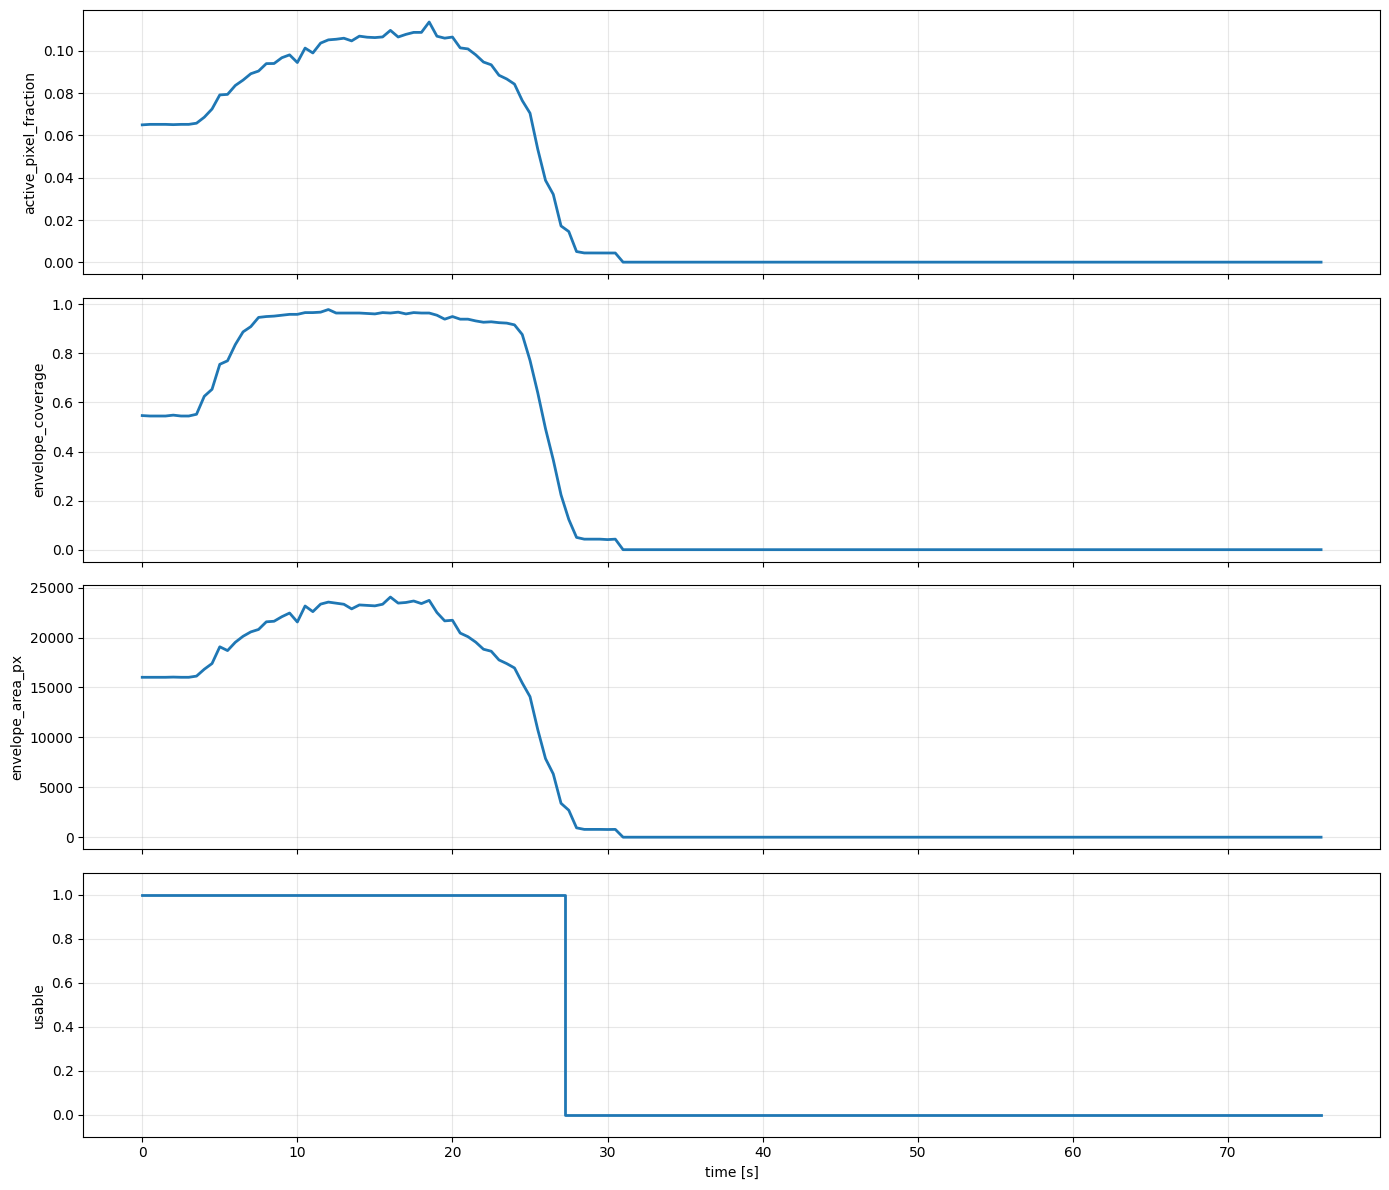

In [20]:
image_qc_df = run_image_quality_scan_for_video(
    video_path=LONG_VIDEO_PATH,
    sample_step_s=0.5,
)

image_qc_summary = summarize_frame_quality_segment(
    image_qc_df
)

print("Image QC summary")
print("=" * 72)

for key, value in image_qc_summary.items():
    print(f"{key}: {value}")

plot_image_quality_scan(
    image_qc_df
)

In [21]:
AUDIO_EXPORT_DIR = Path("audio_exports")
AUDIO_EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

long_audio_path = extract_audio_to_wav(
    video_path=LONG_VIDEO_PATH,
    output_dir=AUDIO_EXPORT_DIR,
    output_name="candidate_long_quality_test_audio.wav",
    sample_rate=None,
    mono=True,
    overwrite=True,
)

print("Extracted audio path:")
print(long_audio_path)

Extracted audio:
  input:  D:\code\DopplerLab\ultrasound_recordings\candidate_long_quality_test.avi
  output: audio_exports\candidate_long_quality_test_audio.wav
Extracted audio path:
audio_exports\candidate_long_quality_test_audio.wav


In [22]:
audio_qc_result, audio_beat_df, audio_summary_df = process_audio_recording_with_qc(
    audio_path=long_audio_path,
)

print("Audio QC summary")
print("=" * 72)

display(audio_summary_df)

print("Audio result keys")
print("=" * 72)
print(audio_qc_result.keys())

display(audio_beat_df.head())

audio_exports\candidate_long_quality_test_audio.wav
Sample rate : 96,000 Hz
Duration : 76.448 s
Samples : 7,339,008

Min value : -0.6598
Max value : 0.7310
Mean : -0.000006
Std : 0.024095
Detected beats: 98
Mean RR: 0.776 s
Estimated HR: 77.3 bpm
Audio QC summary


,n_detected_beats,n_centroid_valid_beats,n_final_valid_beats,n_consecutive_final_rr,centroid_valid_fraction,final_valid_fraction,mean_rr_s,std_rr_s,mean_hr_bpm,mean_centroid_hz,max_centroid_hz,min_centroid_hz,recording_duration_s,usable_start_s,usable_end_s,segment_usable_duration_s,segment_usable_fraction,energy_threshold,qc_centroid_fraction
0,98,94,28,25,0.959184,0.285714,0.83584,0.021783,71.784074,1619.680325,1936.043667,826.585274,76.448,0.592,27.269333,26.677333,0.349009,0.2,0.8


Audio result keys
dict_keys(['audio_path', 'signal', 'sample_rate', 'freqs', 'spectrogram_times', 'Sxx', 'centroid_times', 'centroid', 'peak_idx', 'peak_times', 'peak_values', 'band_energy_times', 'band_energy', 'usable_segment'])


,beat_id,beat_time_s,peak_centroid_hz,rr_interval_s,median_centroid_hz,qc_threshold_hz,is_valid_centroid,is_inside_usable_segment,is_valid_final,is_consecutive_final_valid
0,1,0.672000,1927.057538,NaN,1010.004424,808.003539,True,True,True,False
1,2,1.536000,1936.043667,0.864000,1010.004424,808.003539,True,True,True,True
2,3,2.357333,1851.810508,0.821333,1010.004424,808.003539,True,True,True,True
3,4,3.178667,1851.614006,0.821333,1010.004424,808.003539,True,True,True,True
4,5,4.010667,1865.874139,0.832000,1010.004424,808.003539,True,True,True,True


## Step 2 - Compare image and audio usable segments

This step compares the usable Doppler segment detected by image QC with the usable Doppler segment detected by audio QC.

The comparison is performed at segment level, not beat level.

The goal is to quantify whether both modalities identify the same usable part of the recording.

Computed metrics:

- image usable start and end time
- audio usable start and end time
- start-time difference
- end-time difference
- overlap duration
- union duration
- intersection-over-union agreement score

A high overlap and similar end time suggest that image QC and audio QC are detecting the same physiological-quality recording segment.

In [23]:
def compare_usable_segments(image_summary, audio_summary_df):
    """
    Compare image-derived and audio-derived usable recording segments.
    """
    image_start = float(image_summary["image_usable_start_s"])
    image_end = float(image_summary["image_usable_end_s"])

    audio_row = audio_summary_df.iloc[0]
    audio_start = float(audio_row["usable_start_s"])
    audio_end = float(audio_row["usable_end_s"])

    overlap_start = max(image_start, audio_start)
    overlap_end = min(image_end, audio_end)
    overlap_duration = max(0.0, overlap_end - overlap_start)

    union_start = min(image_start, audio_start)
    union_end = max(image_end, audio_end)
    union_duration = max(0.0, union_end - union_start)

    if union_duration > 0:
        iou = overlap_duration / union_duration
    else:
        iou = np.nan

    comparison = {
        "image_start_s": image_start,
        "image_end_s": image_end,
        "image_duration_s": image_end - image_start,
        "audio_start_s": audio_start,
        "audio_end_s": audio_end,
        "audio_duration_s": audio_end - audio_start,
        "start_difference_s": audio_start - image_start,
        "end_difference_s": audio_end - image_end,
        "overlap_start_s": overlap_start,
        "overlap_end_s": overlap_end,
        "overlap_duration_s": overlap_duration,
        "union_duration_s": union_duration,
        "segment_iou": iou,
    }

    return pd.DataFrame([comparison])

In [24]:
segment_comparison_df = compare_usable_segments(
    image_summary=image_qc_summary,
    audio_summary_df=audio_summary_df,
)

display(segment_comparison_df.T)

,0
image_start_s,0.000000
image_end_s,27.000000
image_duration_s,27.000000
audio_start_s,0.592000
audio_end_s,27.269333
audio_duration_s,26.677333
start_difference_s,0.592000
end_difference_s,0.269333
overlap_start_s,0.592000
overlap_end_s,27.000000


## Step 3 - Visualize image/audio usable segment agreement

This step visualizes the image-derived and audio-derived usable Doppler segments on a shared recording timeline.

The purpose is to make the segment-level agreement easy to inspect visually.

This plot is not a synchronization plot yet. It only compares detected usable time ranges.

In [25]:
def plot_usable_segment_agreement(segment_comparison_df, title="Image/audio usable segment agreement"):
    """
    Plot image-derived and audio-derived usable Doppler segments
    on a shared recording timeline.
    """
    row = segment_comparison_df.iloc[0]

    image_start = float(row["image_start_s"])
    image_end = float(row["image_end_s"])
    audio_start = float(row["audio_start_s"])
    audio_end = float(row["audio_end_s"])

    union_start = min(image_start, audio_start)
    union_end = max(image_end, audio_end)

    fig, ax = plt.subplots(figsize=(12, 3))

    ax.hlines(
        y=1,
        xmin=image_start,
        xmax=image_end,
        linewidth=8,
        label="image usable segment",
    )

    ax.hlines(
        y=0,
        xmin=audio_start,
        xmax=audio_end,
        linewidth=8,
        label="audio usable segment",
    )

    ax.axvline(image_start, linestyle="--", linewidth=1)
    ax.axvline(image_end, linestyle="--", linewidth=1)
    ax.axvline(audio_start, linestyle=":", linewidth=1)
    ax.axvline(audio_end, linestyle=":", linewidth=1)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["audio QC", "image QC"])

    ax.set_xlabel("time [s]")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="center")

    ax.set_xlim(
        max(0.0, union_start - 2.0),
        union_end + 2.0,
    )

    plt.show()

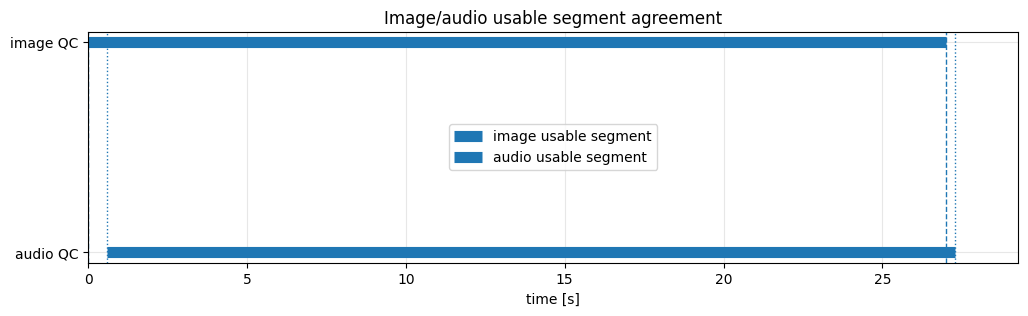

In [26]:
plot_usable_segment_agreement(segment_comparison_df)

## Step 4 - Validation on additional recordings

The image-audio agreement observed on the exploratory long recording may be recording-specific.

This step evaluates the same workflow on additional Doppler recordings:

- candidate_1.avi
- candidate_2.avi
- candidate_3.avi

The objective is to determine whether image QC and audio QC continue to identify similar usable Doppler segments across different recordings.

For each recording the following metrics are collected:

- image usable duration
- audio usable duration
- overlap duration
- intersection-over-union (IoU)
- start-time difference
- end-time difference

The exploratory long recording is treated as the development recording.

The additional recordings are treated as validation recordings.

In [27]:
def run_image_audio_qc_test_recording(
    recording_name,
    video_path,
    audio_export_dir,
    image_sample_step_s=0.5,
    overwrite_audio=True,
):
    """
    Run the NB03 image-audio QC testing pipeline for one Doppler recording.

    This function:
    1. runs image QC directly on the video file,
    2. extracts audio from the video file,
    3. runs audio QC on the extracted WAV file,
    4. compares image and audio usable segments,
    5. returns all intermediate and summary outputs.

    It does not perform beat synchronization.
    """
    video_path = Path(video_path)
    audio_export_dir = Path(audio_export_dir)
    audio_export_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 80)
    print(f"Recording: {recording_name}")
    print("=" * 80)
    print(f"Video path: {video_path}")
    print(f"Exists:     {video_path.exists()}")
    print()

    if not video_path.exists():
        raise FileNotFoundError(f"Video file does not exist: {video_path}")

    print("Running image QC...")
    image_qc_df = run_image_quality_scan_for_video(
        video_path=video_path,
        sample_step_s=image_sample_step_s,
    )

    image_qc_summary = summarize_frame_quality_segment(
        image_qc_df
    )

    print("Image QC summary")
    print("-" * 80)
    for key, value in image_qc_summary.items():
        print(f"{key}: {value}")
    print()

    audio_output_name = f"{recording_name}_audio.wav"

    print("Extracting audio...")
    audio_path = extract_audio_to_wav(
        video_path=video_path,
        output_dir=audio_export_dir,
        output_name=audio_output_name,
        sample_rate=None,
        mono=True,
        overwrite=overwrite_audio,
    )

    print()
    print("Running audio QC...")
    audio_qc_result, audio_beat_df, audio_summary_df = process_audio_recording_with_qc(
        audio_path=audio_path,
    )

    print()
    print("Audio QC summary")
    print("-" * 80)
    display(audio_summary_df)

    segment_comparison_df = compare_usable_segments(
        image_summary=image_qc_summary,
        audio_summary_df=audio_summary_df,
    )

    segment_comparison_df.insert(
        0,
        "recording_name",
        recording_name,
    )

    print()
    print("Segment agreement")
    print("-" * 80)
    display(segment_comparison_df.T)

    result = {
        "recording_name": recording_name,
        "video_path": video_path,
        "audio_path": audio_path,
        "image_qc_df": image_qc_df,
        "image_qc_summary": image_qc_summary,
        "audio_qc_result": audio_qc_result,
        "audio_beat_df": audio_beat_df,
        "audio_summary_df": audio_summary_df,
        "segment_comparison_df": segment_comparison_df,
    }

    return result

In [28]:
candidate_1_result = run_image_audio_qc_test_recording(
    recording_name="candidate_1",
    video_path=new_candidate_paths["new_candidate_avi_1"],
    audio_export_dir=AUDIO_EXPORT_DIR,
    image_sample_step_s=0.5,
    overwrite_audio=True,
)

Recording: candidate_1
Video path: D:\code\DopplerLab\ultrasound_recordings\candidate_1.avi
Exists:     True

Running image QC...
Image QC summary
--------------------------------------------------------------------------------
image_usable_start_s: 0.5
image_usable_end_s: 3.0
image_usable_duration_s: 2.5
image_usable_fraction: 0.05813953488372093
n_total_sampled_frames: 87
n_usable_frames: 5
total_duration_s: 43.0

Extracting audio...
Extracted audio:
  input:  D:\code\DopplerLab\ultrasound_recordings\candidate_1.avi
  output: audio_exports\candidate_1_audio.wav

Running audio QC...
audio_exports\candidate_1_audio.wav
Sample rate : 96,000 Hz
Duration : 43.296 s
Samples : 4,156,416

Min value : -0.2379
Max value : 0.2258
Mean : -0.000000
Std : 0.025583
Detected beats: 57
Mean RR: 0.761 s
Estimated HR: 78.9 bpm

Audio QC summary
--------------------------------------------------------------------------------


,n_detected_beats,n_centroid_valid_beats,n_final_valid_beats,n_consecutive_final_rr,centroid_valid_fraction,final_valid_fraction,mean_rr_s,std_rr_s,mean_hr_bpm,mean_centroid_hz,max_centroid_hz,min_centroid_hz,recording_duration_s,usable_start_s,usable_end_s,segment_usable_duration_s,segment_usable_fraction,energy_threshold,qc_centroid_fraction
0,57,50,49,42,0.877193,0.859649,0.805841,0.228682,74.45635,939.71058,1074.778345,756.113825,43.296,0.853333,43.285333,42.432,0.980286,0.2,0.8



Segment agreement
--------------------------------------------------------------------------------


,0
recording_name,candidate_1
image_start_s,0.5
image_end_s,3.0
image_duration_s,2.5
audio_start_s,0.853333
audio_end_s,43.285333
audio_duration_s,42.432
start_difference_s,0.353333
end_difference_s,40.285333
overlap_start_s,0.853333


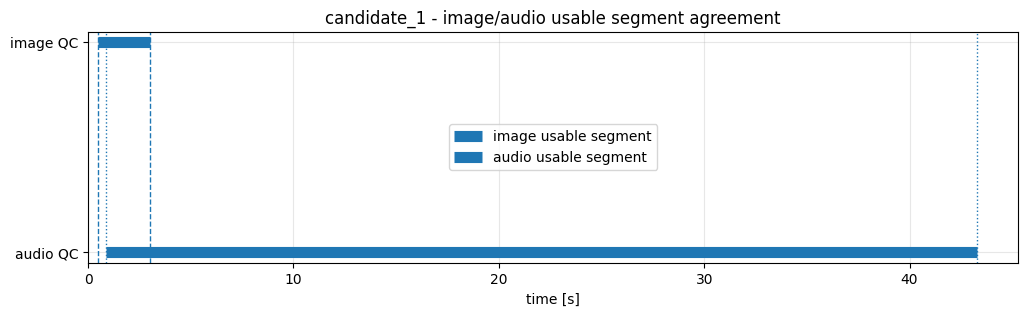

In [29]:
plot_usable_segment_agreement(candidate_1_result["segment_comparison_df"], title="candidate_1 - image/audio usable segment agreement")

In [30]:
candidate_2_result = run_image_audio_qc_test_recording(
    recording_name="candidate_2",
    video_path=new_candidate_paths["new_candidate_avi_2"],
    audio_export_dir=AUDIO_EXPORT_DIR,
    image_sample_step_s=0.5,
    overwrite_audio=True,
)

Recording: candidate_2
Video path: D:\code\DopplerLab\ultrasound_recordings\candidate_2.avi
Exists:     True

Running image QC...
Image QC summary
--------------------------------------------------------------------------------
image_usable_start_s: 0.0
image_usable_end_s: 34.0
image_usable_duration_s: 34.5
image_usable_fraction: 1.0147058823529411
n_total_sampled_frames: 69
n_usable_frames: 69
total_duration_s: 34.0

Extracting audio...
Extracted audio:
  input:  D:\code\DopplerLab\ultrasound_recordings\candidate_2.avi
  output: audio_exports\candidate_2_audio.wav

Running audio QC...
audio_exports\candidate_2_audio.wav
Sample rate : 96,000 Hz
Duration : 34.219 s
Samples : 3,284,992

Min value : -0.0391
Max value : 0.0402
Mean : 0.000000
Std : 0.007193
Detected beats: 38
Mean RR: 0.905 s
Estimated HR: 66.3 bpm

Audio QC summary
--------------------------------------------------------------------------------


,n_detected_beats,n_centroid_valid_beats,n_final_valid_beats,n_consecutive_final_rr,centroid_valid_fraction,final_valid_fraction,mean_rr_s,std_rr_s,mean_hr_bpm,mean_centroid_hz,max_centroid_hz,min_centroid_hz,recording_duration_s,usable_start_s,usable_end_s,segment_usable_duration_s,segment_usable_fraction,energy_threshold,qc_centroid_fraction
0,38,33,32,28,0.868421,0.842105,0.902095,0.041033,66.511824,1353.180021,1621.071526,1089.182408,34.218667,0.405333,34.208,33.802667,0.988151,0.2,0.8



Segment agreement
--------------------------------------------------------------------------------


,0
recording_name,candidate_2
image_start_s,0.0
image_end_s,34.0
image_duration_s,34.0
audio_start_s,0.405333
audio_end_s,34.208
audio_duration_s,33.802667
start_difference_s,0.405333
end_difference_s,0.208
overlap_start_s,0.405333


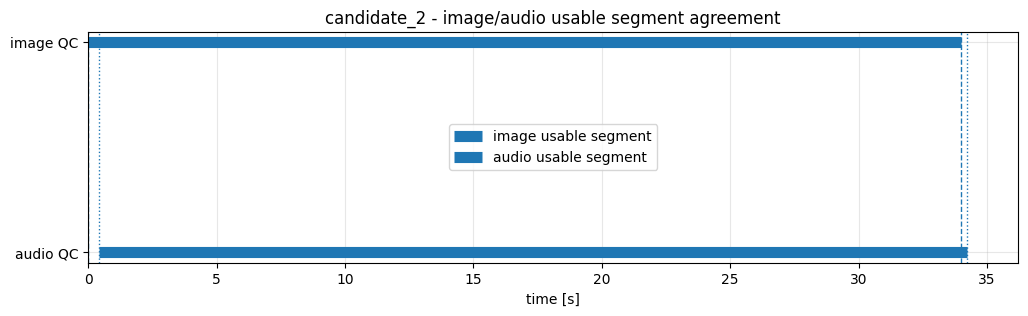

In [31]:
plot_usable_segment_agreement(candidate_2_result["segment_comparison_df"], title="candidate_2 - image/audio usable segment agreement")

In [32]:
candidate_3_result = run_image_audio_qc_test_recording(
    recording_name="candidate_3",
    video_path=new_candidate_paths["new_candidate_avi_3"],
    audio_export_dir=AUDIO_EXPORT_DIR,
    image_sample_step_s=0.5,
    overwrite_audio=True,
)

Recording: candidate_3
Video path: D:\code\DopplerLab\ultrasound_recordings\candidate_3.avi
Exists:     True

Running image QC...
Image QC summary
--------------------------------------------------------------------------------
image_usable_start_s: 0.0
image_usable_end_s: 18.5
image_usable_duration_s: 19.0
image_usable_fraction: 0.8837209302325582
n_total_sampled_frames: 44
n_usable_frames: 38
total_duration_s: 21.5

Extracting audio...
Extracted audio:
  input:  D:\code\DopplerLab\ultrasound_recordings\candidate_3.avi
  output: audio_exports\candidate_3_audio.wav

Running audio QC...
audio_exports\candidate_3_audio.wav
Sample rate : 96,000 Hz
Duration : 21.525 s
Samples : 2,066,432

Min value : -0.0470
Max value : 0.0402
Mean : -0.000000
Std : 0.005512
Detected beats: 38
Mean RR: 0.561 s
Estimated HR: 106.9 bpm

Audio QC summary
--------------------------------------------------------------------------------


,n_detected_beats,n_centroid_valid_beats,n_final_valid_beats,n_consecutive_final_rr,centroid_valid_fraction,final_valid_fraction,mean_rr_s,std_rr_s,mean_hr_bpm,mean_centroid_hz,max_centroid_hz,min_centroid_hz,recording_duration_s,usable_start_s,usable_end_s,segment_usable_duration_s,segment_usable_fraction,energy_threshold,qc_centroid_fraction
0,38,37,34,32,0.973684,0.894737,0.554167,0.123175,108.270677,916.014503,1111.097417,748.197738,21.525333,0.554667,20.026667,19.472,0.905057,0.2,0.8



Segment agreement
--------------------------------------------------------------------------------


,0
recording_name,candidate_3
image_start_s,0.0
image_end_s,18.5
image_duration_s,18.5
audio_start_s,0.554667
audio_end_s,20.026667
audio_duration_s,19.472
start_difference_s,0.554667
end_difference_s,1.526667
overlap_start_s,0.554667


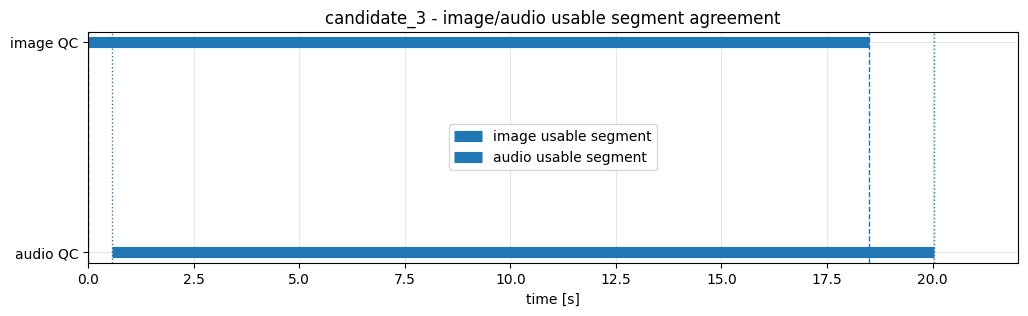

In [33]:
plot_usable_segment_agreement(candidate_3_result["segment_comparison_df"], title="candidate_3 - image/audio usable segment agreement")

In [34]:
validation_summary_df = pd.concat(
    [
        candidate_1_result["segment_comparison_df"],
        candidate_2_result["segment_comparison_df"],
        candidate_3_result["segment_comparison_df"],
    ],
    ignore_index=True,
)

display(validation_summary_df)

,recording_name,image_start_s,image_end_s,image_duration_s,audio_start_s,audio_end_s,audio_duration_s,start_difference_s,end_difference_s,overlap_start_s,overlap_end_s,overlap_duration_s,union_duration_s,segment_iou
0,candidate_1,0.5,3.0,2.5,0.853333,43.285333,42.432000,0.353333,40.285333,0.853333,3.0,2.146667,42.785333,0.050173
1,candidate_2,0.0,34.0,34.0,0.405333,34.208000,33.802667,0.405333,0.208000,0.405333,34.0,33.594667,34.208000,0.982070
2,candidate_3,0.0,18.5,18.5,0.554667,20.026667,19.472000,0.554667,1.526667,0.554667,18.5,17.945333,20.026667,0.896072


In [35]:
validation_summary_df["interpretation"] = [
    "discordant case - audio remains valid but image QC detects poor visual Doppler envelope",
    "agreement case",
    "mostly agreement case - audio extends longer than image near end artifact",
]

display(validation_summary_df)

,recording_name,image_start_s,image_end_s,image_duration_s,audio_start_s,audio_end_s,audio_duration_s,start_difference_s,end_difference_s,overlap_start_s,overlap_end_s,overlap_duration_s,union_duration_s,segment_iou,interpretation
0,candidate_1,0.5,3.0,2.5,0.853333,43.285333,42.432000,0.353333,40.285333,0.853333,3.0,2.146667,42.785333,0.050173,discordant case - audio remains valid but imag...
1,candidate_2,0.0,34.0,34.0,0.405333,34.208000,33.802667,0.405333,0.208000,0.405333,34.0,33.594667,34.208000,0.982070,agreement case
2,candidate_3,0.0,18.5,18.5,0.554667,20.026667,19.472000,0.554667,1.526667,0.554667,18.5,17.945333,20.026667,0.896072,mostly agreement case - audio extends longer t...


## Validation observations

The validation recordings show that image/audio QC agreement depends on recording quality.

`candidate_1.avi` behaves as a discordant case. Audio QC detects a long usable segment, but image QC identifies only a short usable segment. This is consistent with visual inspection: the Doppler audio is still rhythmical, but the image-derived Doppler envelope is weak and not suitable for reliable image-based waveform extraction.

`candidate_2.avi` behaves as an agreement case. Image QC and audio QC identify similar usable segments across most of the recording.

`candidate_3.avi` behaves as a mostly-agreement case. The image and audio segments strongly overlap, but audio QC extends slightly beyond the image-derived usable segment near the end of the recording. This likely reflects residual Doppler sound or motion-related audio activity after the visual waveform quality has already degraded.

These results suggest that image QC and audio QC are complementary rather than redundant.

Image QC is stricter for visual waveform quality.

Audio QC is sensitive to rhythmic Doppler sound and may remain positive when the visual envelope is no longer reliable.

## Step 5 - Investigate the candidate_1 disagreement case

`candidate_1.avi` produced a strong disagreement between image QC and audio QC.

Image QC identified only a short usable segment:

- 0.5 s to 3.0 s

Audio QC identified a much longer usable segment:

- 0.85 s to 43.29 s

This section investigates the source of the disagreement.

Possible explanations include:

- weak visual Doppler envelope
- inappropriate image QC thresholds
- persistent Doppler audio despite poor image quality
- audio QC false positives
- modality-specific sensitivity differences

The objective is not to determine which modality is correct.

The objective is to understand why the modalities disagree.

In [36]:
candidate_1_result["image_qc_df"]

,time_s,baseline,direction,active_pixels,active_pixel_fraction,envelope_coverage,mean_velocity_px,median_velocity_px,p95_velocity_px,envelope_area_px,mean_signal_intensity,is_usable_frame,frame_quality_reason
0,0.0,146,below,2454,0.015651,0.189286,34.528302,28.0,54.50,3660.0,152.417685,False,low_envelope_coverage;low_p95_velocity
1,0.5,146,below,2529,0.016129,0.200000,39.723214,29.5,131.00,4449.0,150.674575,True,ok
2,1.0,146,below,2529,0.016129,0.180357,40.940594,31.0,131.00,4135.0,150.648873,False,low_envelope_coverage
3,1.5,146,below,2529,0.016129,0.200000,39.723214,29.5,131.00,4449.0,150.662317,True,ok
4,2.0,146,below,2519,0.016065,0.200000,39.758929,29.5,131.00,4453.0,150.947995,True,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,41.0,146,above,5400,0.034439,0.332143,35.193548,33.0,54.00,6546.0,148.430926,False,low_p95_velocity
83,41.5,146,above,4597,0.029318,0.269643,36.496689,36.0,54.00,5511.0,148.716119,False,low_p95_velocity
84,42.0,146,below,5529,0.035261,0.317857,35.971910,35.0,60.15,6403.0,163.885332,False,low_p95_velocity
85,42.5,146,below,5139,0.032774,0.294643,35.969697,36.0,60.00,5935.0,162.789648,False,low_p95_velocity


In [38]:
candidate_1_result["image_qc_df"].describe()

,time_s,baseline,active_pixels,active_pixel_fraction,envelope_coverage,mean_velocity_px,median_velocity_px,p95_velocity_px,envelope_area_px,mean_signal_intensity
count,87.000000,87.0,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,21.500000,146.0,4095.229885,0.026118,0.249323,34.720066,31.977011,63.966667,4889.770115,156.840970
std,12.629331,0.0,1160.298696,0.007400,0.048581,3.559294,2.827305,20.055656,1177.958904,6.592278
min,0.000000,146.0,1897.000000,0.012098,0.151786,27.388889,25.000000,40.000000,2356.000000,139.966275
25%,10.750000,146.0,3210.000000,0.020472,0.226786,33.266055,30.000000,58.225000,4403.000000,152.685167
50%,21.500000,146.0,4333.000000,0.027634,0.248214,35.461538,32.500000,62.000000,4982.000000,158.212288
75%,32.250000,146.0,5141.500000,0.032790,0.296429,37.044118,34.000000,66.425000,5909.000000,162.301660
max,43.000000,146.0,5718.000000,0.036467,0.332143,40.940594,36.500000,131.000000,6573.000000,165.377061


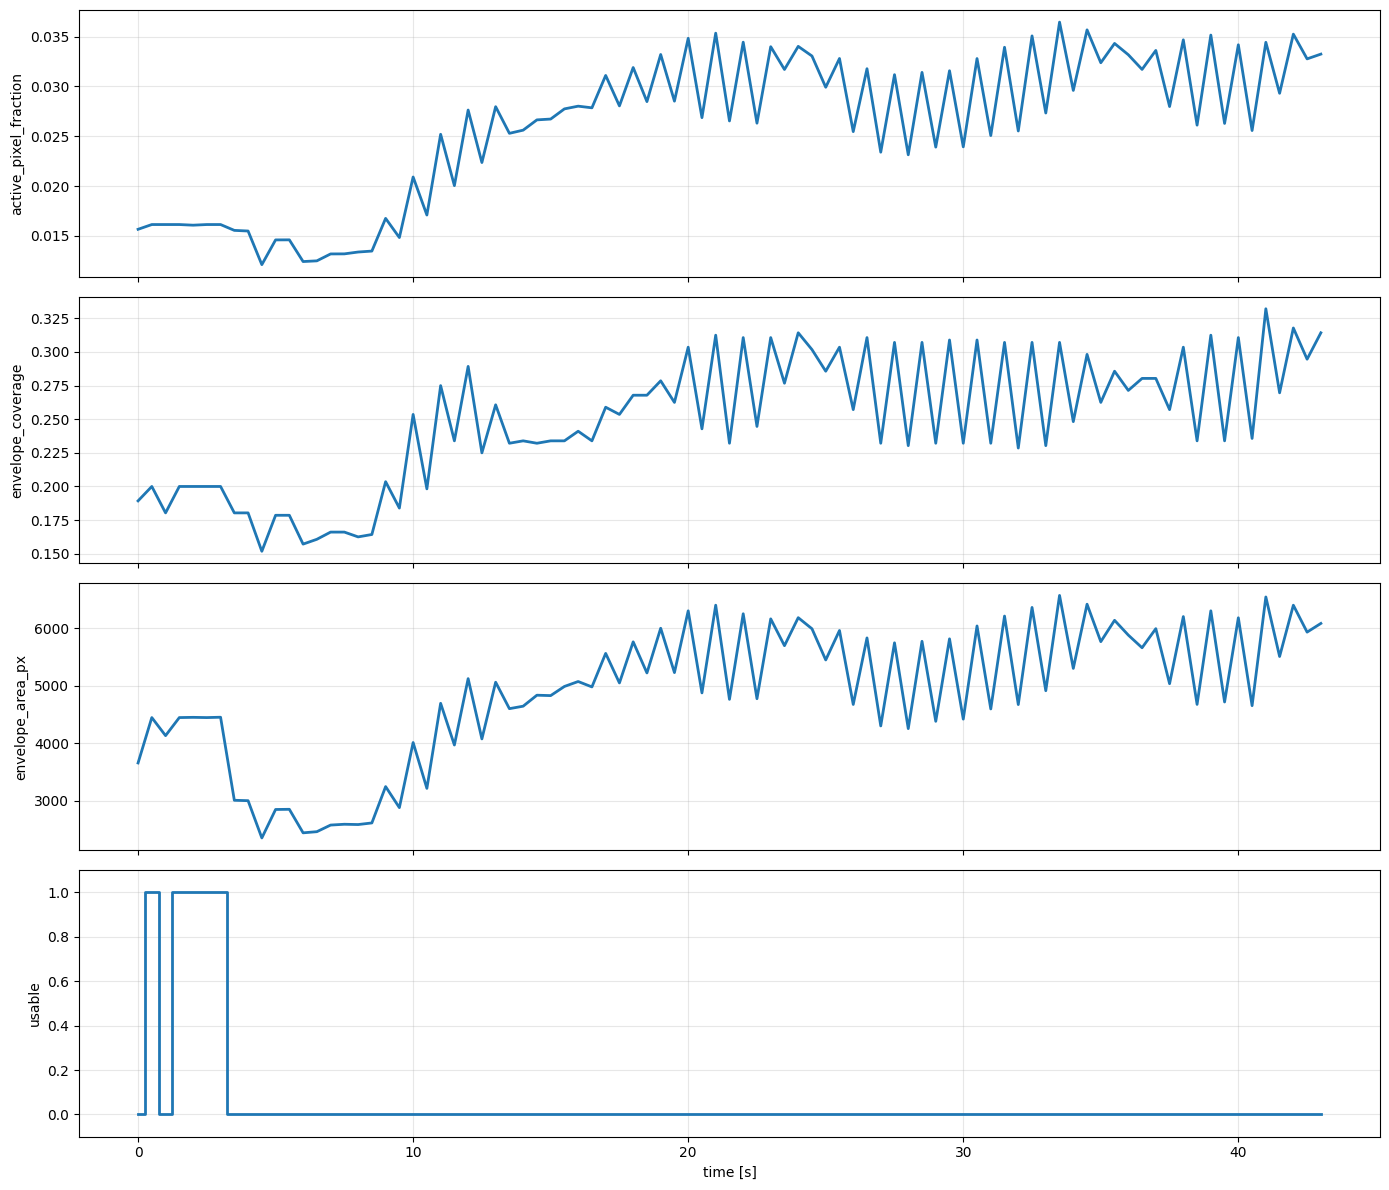

In [40]:
plot_image_quality_scan(candidate_1_result["image_qc_df"])

## Step 5A - Investigate p95 velocity distribution

The disagreement observed in `candidate_1.avi` may be caused by the velocity threshold used by image QC.

The current image QC requires:

- p95_velocity_px >= 70

This section investigates whether the disagreement is caused by:

- genuinely poor Doppler image quality

or

- a Doppler signal with consistently lower velocity values.

The p95 velocity distributions are compared across recordings before any threshold changes are considered.

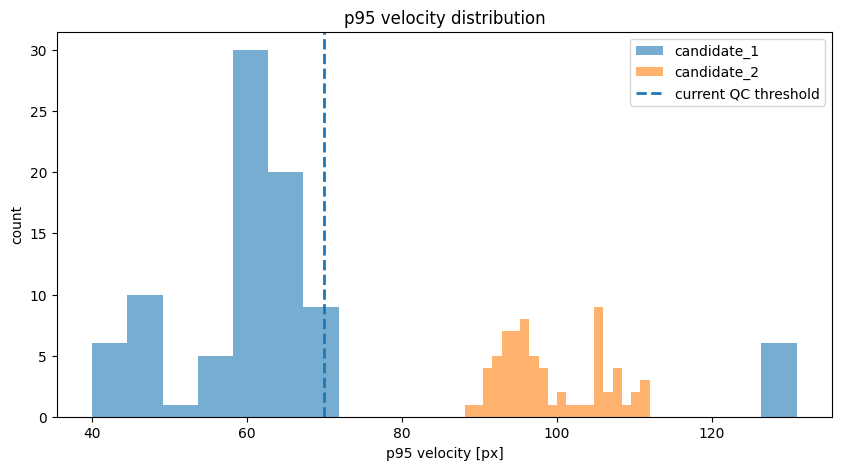

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(
    candidate_1_result["image_qc_df"]["p95_velocity_px"],
    bins=20,
    alpha=0.6,
    label="candidate_1",
)

plt.hist(
    candidate_2_result["image_qc_df"]["p95_velocity_px"],
    bins=20,
    alpha=0.6,
    label="candidate_2",
)

plt.axvline(
    70,
    linestyle="--",
    linewidth=2,
    label="current QC threshold",
)

plt.xlabel("p95 velocity [px]")
plt.ylabel("count")
plt.title("p95 velocity distribution")
plt.legend()

plt.show()

In [42]:
pd.DataFrame(
    {
        "candidate_1": candidate_1_result["image_qc_df"]["p95_velocity_px"].describe(),
        "candidate_2": candidate_2_result["image_qc_df"]["p95_velocity_px"].describe(),
        "candidate_3": candidate_3_result["image_qc_df"]["p95_velocity_px"].describe(),
    }
)

,candidate_1,candidate_2,candidate_3
count,87.000000,69.000000,44.000000
mean,63.966667,99.050725,83.784091
std,20.055656,6.412313,19.785303
min,40.000000,88.100000,59.750000
25%,58.225000,94.000000,76.750000
50%,62.000000,97.000000,78.725000
75%,66.425000,105.400000,80.175000
max,131.000000,112.000000,131.000000


## Step 5B - Image QC threshold sensitivity for candidate_1

The previous analysis suggests that `candidate_1.avi` fails image QC mainly because its p95 velocity values are below the current fixed threshold.

This section tests how sensitive the image usable segment is to the p95 velocity threshold.

The purpose is diagnostic only.

The original image QC pipeline is not changed in this step.

In [43]:
def test_image_qc_p95_threshold_sensitivity(
    image_qc_df,
    p95_thresholds=(70, 65, 60, 55, 50),
    min_active_pixel_fraction=0.01,
    min_envelope_coverage=0.20,
    min_envelope_area_px=3000,
):
    """
    Test how image QC usable-frame decisions change when only the
    p95 velocity threshold is varied.

    This is a diagnostic function. It does not modify the original pipeline.
    """
    rows = []

    for p95_threshold in p95_thresholds:
        tmp_df = image_qc_df.copy()

        tmp_df["is_usable_retested"] = (
            (tmp_df["active_pixel_fraction"] >= min_active_pixel_fraction)
            & (tmp_df["envelope_coverage"] >= min_envelope_coverage)
            & (tmp_df["envelope_area_px"] >= min_envelope_area_px)
            & (tmp_df["p95_velocity_px"] >= p95_threshold)
        )

        usable = tmp_df[tmp_df["is_usable_retested"]]

        if len(usable) > 0:
            usable_start_s = float(usable["time_s"].min())
            usable_end_s = float(usable["time_s"].max())
            usable_duration_s = usable_end_s - usable_start_s + 0.5
        else:
            usable_start_s = np.nan
            usable_end_s = np.nan
            usable_duration_s = 0.0

        rows.append(
            {
                "p95_threshold": p95_threshold,
                "n_usable_frames": int(tmp_df["is_usable_retested"].sum()),
                "usable_fraction": float(tmp_df["is_usable_retested"].mean()),
                "usable_start_s": usable_start_s,
                "usable_end_s": usable_end_s,
                "usable_duration_s": usable_duration_s,
            }
        )

    return pd.DataFrame(rows)

In [44]:
candidate_1_p95_sensitivity_df = test_image_qc_p95_threshold_sensitivity(candidate_1_result["image_qc_df"])
display(candidate_1_p95_sensitivity_df)

,p95_threshold,n_usable_frames,usable_fraction,usable_start_s,usable_end_s,usable_duration_s
0,70,5,0.057471,0.5,3.0,3.0
1,65,28,0.321839,0.5,36.0,36.0
2,60,57,0.655172,0.5,43.0,43.0
3,55,66,0.758621,0.5,43.0,43.0
4,50,68,0.781609,0.5,43.0,43.0


The candidate_1 disagreement is mainly explained by the fixed p95 velocity threshold.

When the p95 threshold is kept at 70 px, image QC detects only 3.0 s of usable signal.

When the threshold is relaxed to 60 px, image QC detects 43.0 s of usable signal, which becomes consistent with the audio QC segment.

This suggests that image QC should not rely only on a fixed absolute velocity threshold across recordings.

A future version should consider recording-adaptive thresholds or multimodal confirmation from audio QC.

In [45]:
def candidate1_iou_vs_p95_threshold(
    image_qc_df,
    audio_start_s,
    audio_end_s,
    p95_thresholds=(70, 65, 60, 55, 50),
):
    """
    Evaluate image/audio segment agreement as a function
    of the image p95 velocity threshold.

    Diagnostic only.
    """
    rows = []

    for threshold in p95_thresholds:

        usable_mask = (
            (image_qc_df["active_pixel_fraction"] >= 0.01)
            & (image_qc_df["envelope_coverage"] >= 0.20)
            & (image_qc_df["envelope_area_px"] >= 3000)
            & (image_qc_df["p95_velocity_px"] >= threshold)
        )

        usable_df = image_qc_df[usable_mask]

        if len(usable_df) == 0:
            rows.append(
                {
                    "p95_threshold": threshold,
                    "image_start_s": np.nan,
                    "image_end_s": np.nan,
                    "image_duration_s": 0.0,
                    "segment_iou": 0.0,
                }
            )
            continue

        image_start = float(usable_df["time_s"].min())
        image_end = float(usable_df["time_s"].max())

        overlap_start = max(image_start, audio_start_s)
        overlap_end = min(image_end, audio_end_s)

        overlap_duration = max(
            0.0,
            overlap_end - overlap_start,
        )

        union_start = min(image_start, audio_start_s)
        union_end = max(image_end, audio_end_s)

        union_duration = max(
            0.0,
            union_end - union_start,
        )

        iou = (
            overlap_duration / union_duration
            if union_duration > 0
            else np.nan
        )

        rows.append(
            {
                "p95_threshold": threshold,
                "image_start_s": image_start,
                "image_end_s": image_end,
                "image_duration_s": image_end - image_start,
                "segment_iou": iou,
            }
        )

    return pd.DataFrame(rows)

In [46]:
audio_row = candidate_1_result["audio_summary_df"].iloc[0]

candidate_1_iou_df = candidate1_iou_vs_p95_threshold(
    image_qc_df=candidate_1_result["image_qc_df"],
    audio_start_s=float(audio_row["usable_start_s"]),
    audio_end_s=float(audio_row["usable_end_s"]),
)

display(candidate_1_iou_df)

,p95_threshold,image_start_s,image_end_s,image_duration_s,segment_iou
0,70,0.5,3.0,2.5,0.050173
1,65,0.5,36.0,35.5,0.821465
2,60,0.5,43.0,42.5,0.985073
3,55,0.5,43.0,42.5,0.985073
4,50,0.5,43.0,42.5,0.985073


## Candidate_1 diagnostic conclusion

The disagreement in `candidate_1.avi` was mainly caused by the fixed image QC p95 velocity threshold.

With the original threshold:

- p95_velocity_px >= 70
- image/audio IoU = 0.050

After lowering only the p95 threshold:

- p95_velocity_px >= 60
- image/audio IoU = 0.985

This means that the visual Doppler signal was not absent. Instead, the recording had a lower image-derived velocity range than the recordings used to define the original threshold.

This result suggests that a fixed absolute velocity threshold may not generalize across Doppler recordings.

Future image QC should consider:

- adaptive velocity thresholds
- recording-specific normalization
- multimodal confirmation using audio QC

In [47]:
def compare_recordings_with_custom_p95_threshold(
    recording_results,
    p95_threshold=60,
    min_active_pixel_fraction=0.01,
    min_envelope_coverage=0.20,
    min_envelope_area_px=3000,
):
    """
    Recompute image/audio segment agreement for multiple recordings
    using a custom image QC p95 velocity threshold.

    Diagnostic only.
    This function does not modify the original pipeline outputs.
    """
    rows = []

    for recording_name, result in recording_results.items():
        image_qc_df = result["image_qc_df"]
        audio_summary_df = result["audio_summary_df"]
        audio_row = audio_summary_df.iloc[0]

        usable_mask = (
            (image_qc_df["active_pixel_fraction"] >= min_active_pixel_fraction)
            & (image_qc_df["envelope_coverage"] >= min_envelope_coverage)
            & (image_qc_df["envelope_area_px"] >= min_envelope_area_px)
            & (image_qc_df["p95_velocity_px"] >= p95_threshold)
        )

        usable_df = image_qc_df[usable_mask]

        if len(usable_df) > 0:
            image_start = float(usable_df["time_s"].min())
            image_end = float(usable_df["time_s"].max())
        else:
            image_start = np.nan
            image_end = np.nan

        audio_start = float(audio_row["usable_start_s"])
        audio_end = float(audio_row["usable_end_s"])

        if np.isnan(image_start) or np.isnan(image_end):
            overlap_duration = 0.0
            union_duration = audio_end - audio_start
            segment_iou = 0.0
        else:
            overlap_start = max(image_start, audio_start)
            overlap_end = min(image_end, audio_end)
            overlap_duration = max(0.0, overlap_end - overlap_start)

            union_start = min(image_start, audio_start)
            union_end = max(image_end, audio_end)
            union_duration = max(0.0, union_end - union_start)

            segment_iou = (
                overlap_duration / union_duration
                if union_duration > 0
                else np.nan
            )

        rows.append(
            {
                "recording_name": recording_name,
                "p95_threshold": p95_threshold,
                "image_start_s": image_start,
                "image_end_s": image_end,
                "audio_start_s": audio_start,
                "audio_end_s": audio_end,
                "overlap_duration_s": overlap_duration,
                "union_duration_s": union_duration,
                "segment_iou": segment_iou,
                "n_image_usable_frames": int(usable_mask.sum()),
                "image_usable_fraction": float(usable_mask.mean()),
            }
        )

    return pd.DataFrame(rows)

In [48]:
recording_results = {
    "candidate_1": candidate_1_result,
    "candidate_2": candidate_2_result,
    "candidate_3": candidate_3_result,
}

p95_60_comparison_df = compare_recordings_with_custom_p95_threshold(
    recording_results=recording_results,
    p95_threshold=60,
)

display(p95_60_comparison_df)

,recording_name,p95_threshold,image_start_s,image_end_s,audio_start_s,audio_end_s,overlap_duration_s,union_duration_s,segment_iou,n_image_usable_frames,image_usable_fraction
0,candidate_1,60,0.5,43.0,0.853333,43.285333,42.146667,42.785333,0.985073,57,0.655172
1,candidate_2,60,0.0,34.0,0.405333,34.208000,33.594667,34.208000,0.982070,69,1.000000
2,candidate_3,60,0.0,19.5,0.554667,20.026667,18.945333,20.026667,0.946005,40,0.909091


## p95 threshold 60 diagnostic result

Lowering the image QC p95 velocity threshold from 70 px to 60 px substantially improved image/audio agreement.

With p95 threshold = 60:

- candidate_1 IoU increased from 0.050 to 0.985
- candidate_2 remained stable at 0.982
- candidate_3 improved from 0.896 to 0.946

IoU means intersection over union. In this notebook it is computed as:

usable segment overlap duration / usable segment union duration

This result suggests that the original p95 threshold of 70 px was too strict for lower-velocity Doppler recordings.

A p95 threshold of 60 px appears more robust across the current validation recordings.

This does not yet prove that 60 px is universally optimal. It should be treated as a candidate threshold for further testing on more recordings.

## Step 6 - Segment-level conclusion

This section summarizes the segment-level image/audio QC agreement across the current recordings.

The goal is to separate three findings:

1. image/audio agreement on stable recordings
2. candidate_1 disagreement under the original fixed p95 threshold
3. improvement after testing a lower p95 threshold diagnostically

No changes are made to the original NB01 or NB02 pipelines in this notebook.

In [49]:
original_threshold_df = validation_summary_df[
    [
        "recording_name",
        "segment_iou",
        "image_duration_s",
        "audio_duration_s",
    ]
].copy()

original_threshold_df["p95_threshold"] = 70
original_threshold_df = original_threshold_df.rename(
    columns={
        "segment_iou": "iou_original_p95_70",
        "image_duration_s": "image_duration_original",
        "audio_duration_s": "audio_duration",
    }
)

p95_60_short_df = p95_60_comparison_df[
    [
        "recording_name",
        "segment_iou",
        "image_start_s",
        "image_end_s",
        "n_image_usable_frames",
        "image_usable_fraction",
    ]
].copy()

p95_60_short_df = p95_60_short_df.rename(
    columns={
        "segment_iou": "iou_diagnostic_p95_60",
        "image_start_s": "image_start_p95_60",
        "image_end_s": "image_end_p95_60",
    }
)

threshold_comparison_df = original_threshold_df.merge(
    p95_60_short_df,
    on="recording_name",
    how="left",
)

threshold_comparison_df["iou_change"] = (
    threshold_comparison_df["iou_diagnostic_p95_60"]
    - threshold_comparison_df["iou_original_p95_70"]
)

display(threshold_comparison_df)

,recording_name,iou_original_p95_70,image_duration_original,audio_duration,p95_threshold,iou_diagnostic_p95_60,image_start_p95_60,image_end_p95_60,n_image_usable_frames,image_usable_fraction,iou_change
0,candidate_1,0.050173,2.5,42.432000,70,0.985073,0.5,43.0,57,0.655172,0.934900
1,candidate_2,0.982070,34.0,33.802667,70,0.982070,0.0,34.0,69,1.000000,0.000000
2,candidate_3,0.896072,18.5,19.472000,70,0.946005,0.0,19.5,40,0.909091,0.049933


## Segment-level conclusion

The segment-level analysis showed that image QC and audio QC usually identify highly similar usable Doppler segments.

With the original image QC p95 threshold of 70 px:

- candidate_2 had very high agreement
- candidate_3 had high agreement
- candidate_1 showed strong disagreement

The candidate_1 disagreement was mainly explained by the fixed p95 velocity threshold.

When the p95 threshold was lowered diagnostically from 70 px to 60 px:

- candidate_1 IoU increased from 0.050 to 0.985
- candidate_2 remained unchanged at 0.982
- candidate_3 improved from 0.896 to 0.946

IoU means intersection over union. In this notebook it measures:

usable segment overlap duration / usable segment union duration

This suggests that a fixed absolute p95 velocity threshold may be too strict for lower-velocity Doppler recordings.

The original NB01 and NB02 pipelines are not changed here.

This result supports future work on:

- adaptive image QC thresholds
- recording-specific normalization
- multimodal QC using both image and audio information

## Step 7 - Image/audio beat-level preparation

Segment-level QC is complete.

This section prepares beat-level synchronization by extracting image-derived beat times and comparing them with audio-derived beat times.

The first test is performed only on the exploratory long recording.

In [57]:
def read_video_frame_at_time(video_path, time_s):
    """
    Read one RGB frame from a video at a requested timestamp.

    This helper is used to test image waveform extraction on a selected
    representative frame before building a full beat-level synchronization
    workflow.
    """
    video_path = Path(video_path)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0:
        cap.release()
        raise RuntimeError(f"Invalid FPS detected for video: {video_path}")

    frame_idx = int(round(time_s * fps))

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    ok, frame_bgr = cap.read()

    cap.release()

    if not ok:
        raise RuntimeError(
            f"Could not read frame at time_s={time_s}, frame_idx={frame_idx}"
        )

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    return {
        "frame_rgb": frame_rgb,
        "fps": fps,
        "frame_idx": frame_idx,
        "time_s": time_s,
    }

In [58]:
long_frame_test = read_video_frame_at_time(video_path=LONG_VIDEO_PATH, time_s=5.0)

print(long_frame_test["fps"])
print(long_frame_test["frame_idx"])
print(long_frame_test["frame_rgb"].shape)

30.0
150
(540, 720, 3)


In [60]:
long_image_result = extract_doppler_waveform(long_frame_test["frame_rgb"])
print(long_image_result.keys())

dict_keys(['roi', 'gray', 'mask', 'baseline', 'direction', 'min_segment_length', 'trim_left', 'trim_right', 'x_offset', 'envelope', 'velocity_raw', 'velocity_med', 'velocity_smooth', 'peaks_local', 'peaks_global', 'peaks', 'peak_props'])


In [61]:
long_image_beat_df = analyze_beats(long_image_result)
display(long_image_beat_df)

,beat_id,is_complete_beat,beat_quality_reason,psv_local,psv_global,psv_value_px,next_psv_local,next_psv_global,first_valley_local,first_valley_global,first_valley_value_px,secondary_peak_local,secondary_peak_global,secondary_peak_value_px,cycle_length_px,time_to_valley_px,time_to_secondary_peak_px,valley_to_psv_ratio,secondary_to_psv_ratio,ri_proxy
0,1,False,missing_secondary_peak,129,139,134.917947,267,277,208,218,9.707748,NaN,NaN,NaN,138,79,NaN,0.071953,NaN,0.928047
1,2,False,valley_too_late;missing_secondary_peak,267,277,136.475319,406,416,386,396,8.336571,NaN,NaN,NaN,139,119,NaN,0.061085,NaN,0.938915


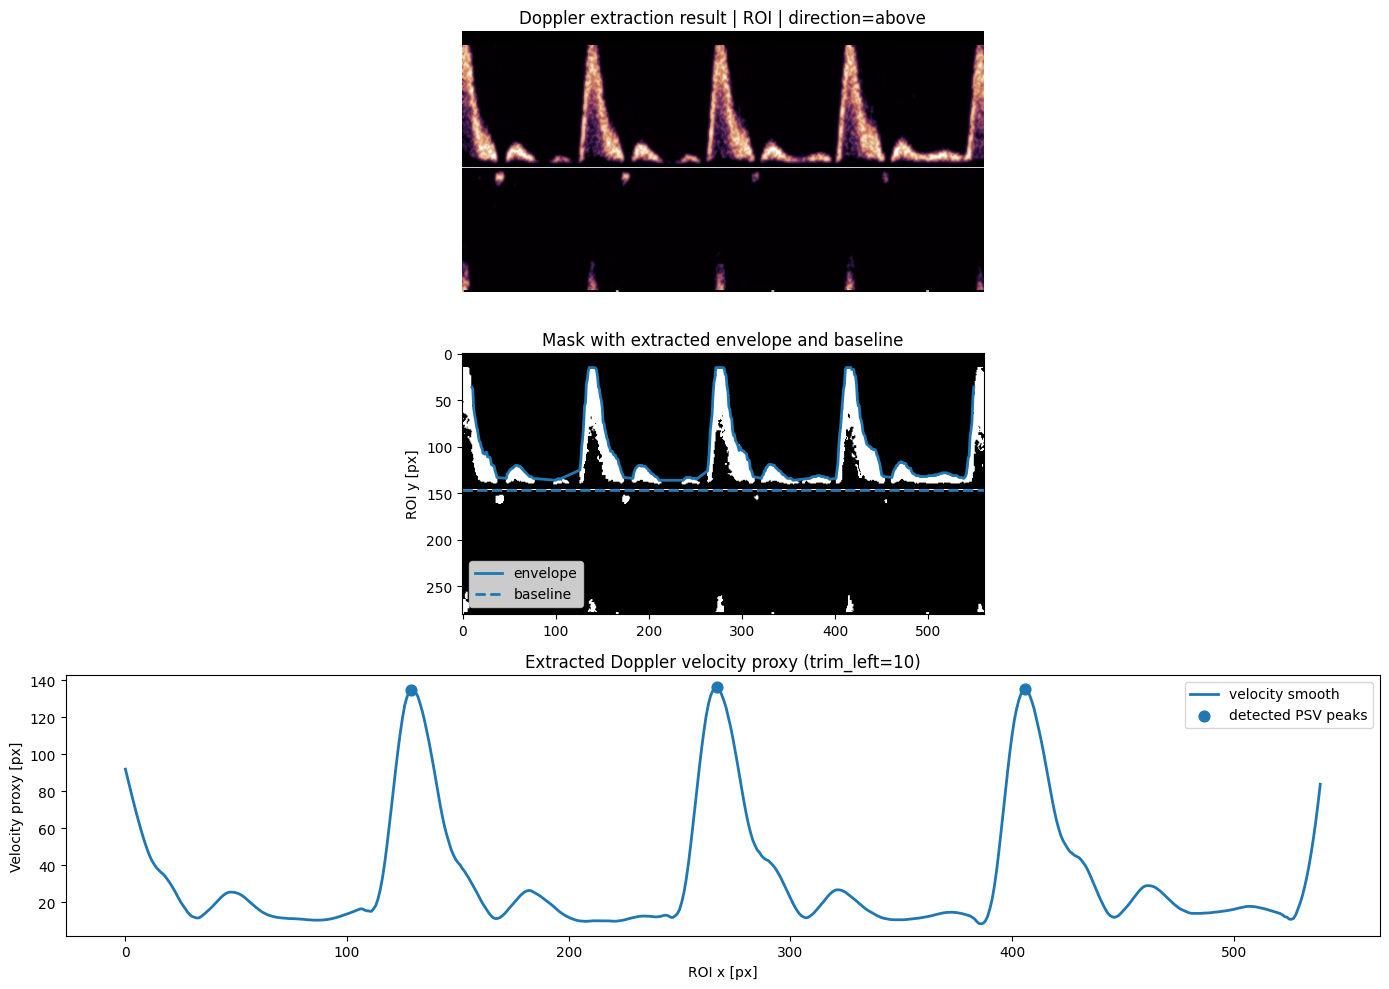

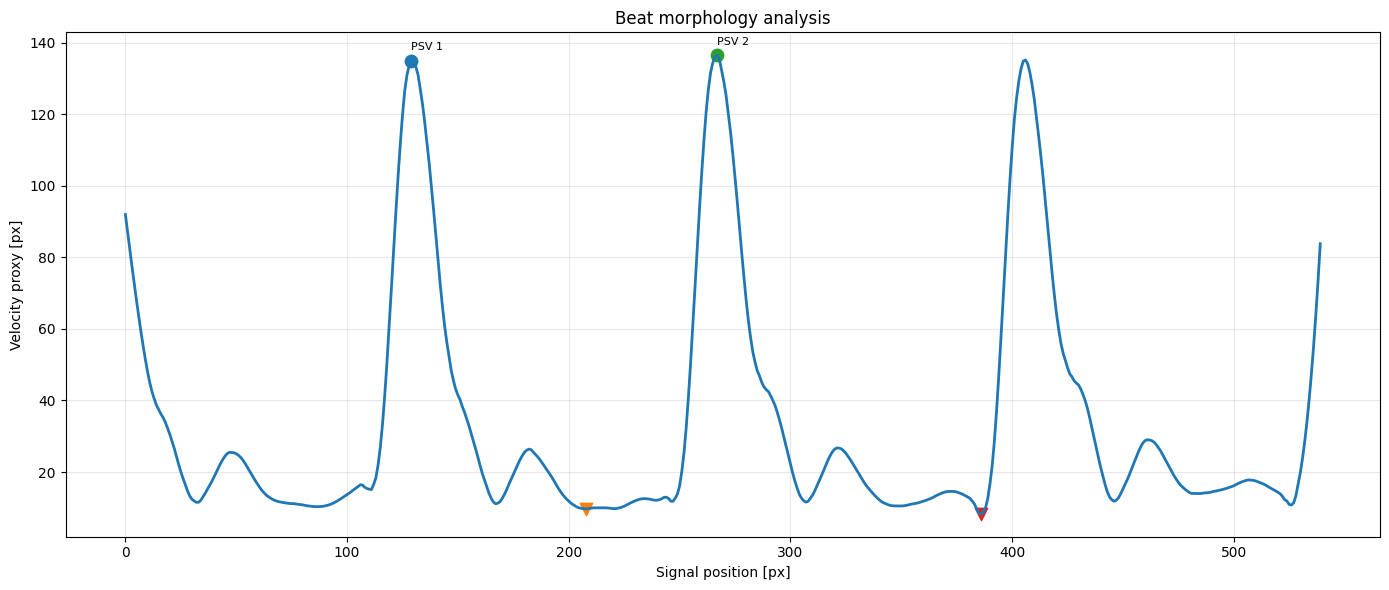

In [62]:
plot_doppler_extraction_result(long_image_result)
plot_beat_analysis(long_image_result, long_image_beat_df)

In [63]:
print("peaks:", long_image_result["peaks"])
print("peaks_global:", long_image_result["peaks_global"])

peaks: [129 267 406]
peaks_global: [139 277 416]


In [64]:
print(long_image_result["peaks_global"])
print(np.diff(long_image_result["peaks_global"]))
print(audio_beat_df.head(10))

[139 277 416]
[138 139]
   beat_id  beat_time_s  peak_centroid_hz  rr_interval_s  median_centroid_hz  \
0        1     0.672000       1927.057538            NaN         1010.004424   
1        2     1.536000       1936.043667       0.864000         1010.004424   
2        3     2.357333       1851.810508       0.821333         1010.004424   
3        4     3.178667       1851.614006       0.821333         1010.004424   
4        5     4.010667       1865.874139       0.832000         1010.004424   
5        6     4.848000       1748.663011       0.837333         1010.004424   
6        7     5.669333       1740.685910       0.821333         1010.004424   
7        8     6.501333       1780.668054       0.832000         1010.004424   
8        9     7.386667       1795.131157       0.885333         1010.004424   
9       10     8.256000       1748.321726       0.869333         1010.004424   

   qc_threshold_hz  is_valid_centroid  is_inside_usable_segment  \
0       808.003539          

In [65]:
def estimate_image_time_scale_from_audio_rr(
    image_peak_x,
    audio_beat_df,
    audio_time_min_s,
    audio_time_max_s,
    rr_column="rr_interval_s",
):
    """
    Estimate Doppler image seconds-per-pixel using image PSV peak spacing
    and audio RR intervals from a matching time window.

    This is a diagnostic calibration step.
    """
    image_peak_x = np.asarray(image_peak_x, dtype=float)

    if len(image_peak_x) < 2:
        raise ValueError("At least two image peaks are required.")

    image_peak_spacing_px = np.diff(image_peak_x)

    audio_window_df = audio_beat_df[
        (audio_beat_df["beat_time_s"] >= audio_time_min_s)
        & (audio_beat_df["beat_time_s"] <= audio_time_max_s)
    ].copy()

    valid_rr = audio_window_df[rr_column].dropna().to_numpy(dtype=float)

    if len(valid_rr) == 0:
        raise ValueError("No valid audio RR intervals found in the selected time window.")

    median_image_spacing_px = float(np.median(image_peak_spacing_px))
    mean_image_spacing_px = float(np.mean(image_peak_spacing_px))

    median_audio_rr_s = float(np.median(valid_rr))
    mean_audio_rr_s = float(np.mean(valid_rr))

    seconds_per_pixel_median = median_audio_rr_s / median_image_spacing_px
    seconds_per_pixel_mean = mean_audio_rr_s / mean_image_spacing_px

    result = {
        "n_image_peaks": int(len(image_peak_x)),
        "image_peak_spacing_px": image_peak_spacing_px,
        "median_image_spacing_px": median_image_spacing_px,
        "mean_image_spacing_px": mean_image_spacing_px,
        "n_audio_rr": int(len(valid_rr)),
        "median_audio_rr_s": median_audio_rr_s,
        "mean_audio_rr_s": mean_audio_rr_s,
        "seconds_per_pixel_median": seconds_per_pixel_median,
        "seconds_per_pixel_mean": seconds_per_pixel_mean,
        "milliseconds_per_pixel_median": seconds_per_pixel_median * 1000,
        "milliseconds_per_pixel_mean": seconds_per_pixel_mean * 1000,
    }

    return result

In [66]:
long_time_scale_estimate = estimate_image_time_scale_from_audio_rr(
    image_peak_x=long_image_result["peaks_global"],
    audio_beat_df=audio_beat_df,
    audio_time_min_s=4.0,
    audio_time_max_s=7.0,
)

for key, value in long_time_scale_estimate.items():
    print(f"{key}: {value}")

n_image_peaks: 3
image_peak_spacing_px: [138. 139.]
median_image_spacing_px: 138.5
mean_image_spacing_px: 138.5
n_audio_rr: 4
median_audio_rr_s: 0.8319999999999999
mean_audio_rr_s: 0.8306666666666667
seconds_per_pixel_median: 0.006007220216606497
seconds_per_pixel_mean: 0.005997593261131167
milliseconds_per_pixel_median: 6.007220216606497
milliseconds_per_pixel_mean: 5.997593261131167


## Step 7A - Image time-axis calibration

The Doppler image contains a scrolling time-history waveform.

Before image/audio beat synchronization can be tested, the horizontal image axis must be converted from pixels to seconds.

In this diagnostic step, the image time scale was estimated from:

- spacing between image PSV peaks
- audio-derived RR intervals from the corresponding recording window

For the exploratory long recording, the estimated image time scale was:

- approximately 0.0060 s/px
- approximately 6.0 ms/px

This means that a 560 px Doppler waveform window represents approximately 3.36 seconds of signal history.

This estimate is not yet a universal calibration. It is a practical diagnostic estimate for the current recording and device export format.

In [67]:
def estimate_image_peak_times(
    image_peak_x,
    frame_time_s,
    waveform_width_px,
    seconds_per_pixel,
):
    """
    Convert Doppler image peak positions into estimated recording times.

    Assumption:
    The right edge of the waveform corresponds approximately
    to the frame acquisition time.
    """
    image_peak_x = np.asarray(image_peak_x, dtype=float)

    peak_times_s = (
        frame_time_s
        - (waveform_width_px - image_peak_x)
        * seconds_per_pixel
    )

    return peak_times_s

In [68]:
estimated_image_peak_times = estimate_image_peak_times(
    image_peak_x=long_image_result["peaks_global"],
    frame_time_s=5.0,
    waveform_width_px=len(long_image_result["velocity_smooth"]),
    seconds_per_pixel=long_time_scale_estimate["seconds_per_pixel_median"],
)

print("Estimated image peak times:")
print(np.round(estimated_image_peak_times, 3))

Estimated image peak times:
[2.591 3.42  4.255]


## Step 7A conclusion

The image-derived PSV spacing and audio-derived RR intervals were highly consistent.

Image peak spacing:

- 138 px
- 139 px

Estimated image timing:

- approximately 0.83 s between beats

Audio RR intervals from the same recording window:

- approximately 0.82–0.84 s

This suggests that the Doppler image time calibration is internally consistent and that image-derived and audio-derived beat timing are describing the same physiological rhythm.

This does not yet constitute beat synchronization.

It demonstrates that both modalities produce compatible beat intervals.

## Step 7B - Temporal calibration stability

The previous calibration was estimated from a single Doppler frame.

Before image/audio beat synchronization can be investigated further, the stability of the image time-axis calibration should be evaluated.

This section estimates the image time scale at multiple locations within the usable recording segment.

The objective is to determine whether the Doppler image uses a stable time scale throughout the recording.

A stable result would support future beat-level synchronization.

In [69]:
def evaluate_image_time_scale_stability(video_path, frame_times_s, audio_beat_df):
    """
    Estimate image milliseconds-per-pixel at multiple recording times.

    For each selected frame:

    1. read frame
    2. extract Doppler waveform
    3. detect PSV peaks
    4. estimate image time scale from audio RR intervals

    Returns a summary dataframe.
    """
    rows = []

    for frame_time_s in frame_times_s:

        try:
            frame_info = read_video_frame_at_time(
                video_path=video_path,
                time_s=frame_time_s,
            )

            image_result = extract_doppler_waveform(
                frame_info["frame_rgb"]
            )

            peaks_global = image_result["peaks_global"]

            if len(peaks_global) < 3:
                rows.append(
                    {
                        "frame_time_s": frame_time_s,
                        "status": "insufficient_peaks",
                    }
                )
                continue

            estimate = estimate_image_time_scale_from_audio_rr(
                image_peak_x=peaks_global,
                audio_beat_df=audio_beat_df,
                audio_time_min_s=max(0.0, frame_time_s - 2.0),
                audio_time_max_s=frame_time_s + 2.0,
            )

            rows.append(
                {
                    "frame_time_s": frame_time_s,
                    "status": "ok",
                    "n_image_peaks": estimate["n_image_peaks"],
                    "median_spacing_px": estimate["median_image_spacing_px"],
                    "median_rr_s": estimate["median_audio_rr_s"],
                    "ms_per_pixel": estimate["milliseconds_per_pixel_median"],
                }
            )

        except Exception as e:

            rows.append(
                {
                    "frame_time_s": frame_time_s,
                    "status": f"error: {str(e)}",
                }
            )

    return pd.DataFrame(rows)

In [70]:
frame_times_to_test = [
    5.0,
    10.0,
    15.0,
    20.0,
    25.0,
]

time_scale_stability_df = evaluate_image_time_scale_stability(
    video_path=LONG_VIDEO_PATH,
    frame_times_s=frame_times_to_test,
    audio_beat_df=audio_beat_df,
)

display(time_scale_stability_df)

,frame_time_s,status,n_image_peaks,median_spacing_px,median_rr_s,ms_per_pixel
0,5.0,ok,3,138.5,0.832000,6.007220
1,10.0,ok,3,143.0,0.858667,6.004662
2,15.0,ok,4,139.0,0.821333,5.908873
3,20.0,ok,4,136.0,0.826667,6.078431
4,25.0,ok,3,142.0,0.858667,6.046948


## Step 7B conclusion

The image time-axis calibration was stable across multiple frames from the usable segment of the long recording.

The estimated scale remained close to:

- approximately 6.0 ms/px

Across tested frames, the estimated values ranged from approximately:

- 5.91 ms/px to 6.08 ms/px

This suggests that the Doppler image time scale is stable within the usable portion of this recording.

This supports the next step: comparing image-derived peak timing with audio-derived beat timing.

## Step 7C - Nearest audio beat comparison

The previous steps established that:

- image-derived beat spacing is consistent with audio RR intervals
- image time-axis calibration is stable

This step compares image-derived peak times with the nearest audio-derived beat times.

The objective is not full synchronization.

The objective is to determine whether image-derived peaks occur close to audio-derived beats in time.

In [71]:
def compare_image_peaks_to_nearest_audio_beats(image_peak_times_s, audio_beat_times_s):
    """
    Compare image-derived peak times to the nearest
    audio-derived beat times.

    Diagnostic only.
    """
    rows = []

    audio_beat_times_s = np.asarray(audio_beat_times_s, dtype=float)

    for image_time in image_peak_times_s:

        idx = np.argmin(
            np.abs(audio_beat_times_s - image_time)
        )

        nearest_audio_time = float(
            audio_beat_times_s[idx]
        )

        delta_s = image_time - nearest_audio_time

        rows.append(
            {
                "image_peak_time_s": image_time,
                "nearest_audio_beat_s": nearest_audio_time,
                "delta_s": delta_s,
                "delta_ms": delta_s * 1000,
            }
        )

    return pd.DataFrame(rows)

In [72]:
nearest_beat_df = compare_image_peaks_to_nearest_audio_beats(
    image_peak_times_s=estimated_image_peak_times,
    audio_beat_times_s=audio_beat_df["beat_time_s"].values,
)

display(nearest_beat_df)

print()
print(
    "Mean absolute error [ms]:",
    np.mean(np.abs(nearest_beat_df["delta_ms"]))
)

,image_peak_time_s,nearest_audio_beat_s,delta_s,delta_ms
0,2.591105,2.357333,0.233771,233.771360
1,3.420101,3.178667,0.241434,241.434416
2,4.255105,4.010667,0.244438,244.438026



Mean absolute error [ms]: 239.88126754913768


## Step 7C observation

Image-derived peak times were compared with the nearest audio-derived beat times.

The differences were approximately:

- 234 ms
- 241 ms
- 244 ms

This indicates that the beat spacing is consistent between image and audio, but a nearly constant temporal offset exists between the two modalities.

This is expected at this exploratory stage because the Doppler image waveform is a scrolling time-history display, and the exact mapping between frame acquisition time, screen rendering delay, and audio timestamp is not yet calibrated.

The important observation is that the offset is consistent, not random.

A consistent offset can potentially be corrected in a later synchronization step.

In [73]:
median_offset_ms = np.median(
    nearest_beat_df["delta_ms"]
)

median_offset_s = median_offset_ms / 1000

print(f"Median offset: {median_offset_ms:.2f} ms")

Median offset: 241.43 ms


In [74]:
offset_corrected_image_peak_times = (
    estimated_image_peak_times
    - median_offset_s
)

offset_corrected_df = compare_image_peaks_to_nearest_audio_beats(
    image_peak_times_s=offset_corrected_image_peak_times,
    audio_beat_times_s=audio_beat_df["beat_time_s"].values,
)

display(offset_corrected_df)

print()
print(
    "Mean absolute error after correction [ms]:",
    np.mean(np.abs(offset_corrected_df["delta_ms"]))
)

,image_peak_time_s,nearest_audio_beat_s,delta_s,delta_ms
0,2.349670,2.357333,-0.007663,-7.663057
1,3.178667,3.178667,0.000000,0.000000
2,4.013670,4.010667,0.003004,3.003610



Mean absolute error after correction [ms]: 3.55555555555546


## Step 7C conclusion

The nearest-beat comparison showed a nearly constant offset between image-derived peak times and audio-derived beat times.

Before offset correction:

- median offset was approximately 241 ms
- mean absolute error was approximately 240 ms

After subtracting the median offset:

- mean absolute error decreased to approximately 3.6 ms

This suggests that image-derived and audio-derived beat timing are highly consistent after correcting for a constant temporal offset.

The offset may reflect screen rendering delay, scrolling waveform alignment, video/audio timestamp differences, or assumptions about which part of the Doppler display corresponds to frame acquisition time.

This result supports the feasibility of image/audio beat-level synchronization, but the offset should be estimated and validated across more frames and recordings before being treated as a stable device-level parameter.

## Step 7D - Offset stability across frames

The previous analysis showed that image-derived peak timing and audio-derived beat timing become highly consistent after correcting for a constant temporal offset.

This section evaluates whether the estimated offset remains stable across multiple frames from the usable recording segment.

A stable offset would support future image/audio synchronization methods.

An unstable offset would suggest that additional calibration is required.

In [75]:
def evaluate_offset_stability(video_path, frame_times_s, audio_beat_df):
    """
    Estimate image/audio timing offset at multiple frame locations.

    Returns one row per frame.
    """
    rows = []

    for frame_time_s in frame_times_s:

        try:

            frame_info = read_video_frame_at_time(
                video_path=video_path,
                time_s=frame_time_s,
            )

            image_result = extract_doppler_waveform(
                frame_info["frame_rgb"]
            )

            peaks_global = image_result["peaks_global"]

            if len(peaks_global) < 3:
                rows.append(
                    {
                        "frame_time_s": frame_time_s,
                        "status": "insufficient_peaks",
                    }
                )
                continue

            scale_est = estimate_image_time_scale_from_audio_rr(
                image_peak_x=peaks_global,
                audio_beat_df=audio_beat_df,
                audio_time_min_s=max(0.0, frame_time_s - 2.0),
                audio_time_max_s=frame_time_s + 2.0,
            )

            image_peak_times = estimate_image_peak_times(
                image_peak_x=peaks_global,
                frame_time_s=frame_time_s,
                waveform_width_px=len(image_result["velocity_smooth"]),
                seconds_per_pixel=scale_est["seconds_per_pixel_median"],
            )

            nearest_df = compare_image_peaks_to_nearest_audio_beats(
                image_peak_times_s=image_peak_times,
                audio_beat_times_s=audio_beat_df["beat_time_s"].values,
            )

            median_offset_ms = float(
                np.median(nearest_df["delta_ms"])
            )

            mean_abs_error_ms = float(
                np.mean(np.abs(nearest_df["delta_ms"]))
            )

            rows.append(
                {
                    "frame_time_s": frame_time_s,
                    "status": "ok",
                    "n_peaks": len(image_peak_times),
                    "median_offset_ms": median_offset_ms,
                    "mean_abs_error_ms": mean_abs_error_ms,
                }
            )

        except Exception as e:

            rows.append(
                {
                    "frame_time_s": frame_time_s,
                    "status": f"error: {str(e)}",
                }
            )

    return pd.DataFrame(rows)

In [76]:
offset_stability_df = evaluate_offset_stability(
    video_path=LONG_VIDEO_PATH,
    frame_times_s=[5, 10, 15, 20, 25],
    audio_beat_df=audio_beat_df,
)

display(offset_stability_df)

,frame_time_s,status,n_peaks,median_offset_ms,mean_abs_error_ms
0,5,ok,3,241.434416,239.881268
1,10,ok,3,241.491841,239.937840
2,15,ok,4,271.884892,271.597122
3,20,ok,4,221.411765,220.049020
4,25,ok,3,238.497653,241.226917


## Step 7D conclusion

The image/audio timing offset was evaluated across multiple frames from the usable long recording segment.

The estimated median offset was usually close to approximately 240 ms, but it varied across frames:

- minimum observed offset: approximately 221 ms
- maximum observed offset: approximately 272 ms

This suggests that the offset is not random, but it is also not perfectly constant.

The result supports image/audio beat-level synchronization as feasible, but suggests that a single global offset may be too simplistic.

A future synchronization approach should probably estimate offset locally or use multiple frames rather than relying on one fixed correction value for the whole recording.

## Step 7E - Offset-corrected beat matching across multiple frames

The previous step showed that image/audio timing differences are mostly explained by a temporal offset.

This step applies local offset correction independently for multiple frames.

For each tested frame:

1. image PSV peaks are extracted
2. image peak positions are converted to estimated recording times
3. nearest audio beats are identified
4. local median offset is estimated
5. image peak times are corrected by this offset
6. residual timing error is computed

The goal is to determine whether image/audio beat matching remains accurate after local offset correction across multiple frames.

In [77]:
def evaluate_offset_corrected_matching_across_frames(video_path, frame_times_s, audio_beat_df):
    """
    Evaluate offset-corrected image/audio beat matching across multiple frames.

    For each frame:
    - read video frame
    - extract Doppler image waveform
    - detect image PSV peaks
    - estimate image time scale from local audio RR
    - convert image peak positions to estimated recording times
    - estimate local image/audio offset
    - correct image peak times
    - compute residual nearest-audio-beat error
    """
    summary_rows = []
    detail_rows = []

    audio_beat_times_s = audio_beat_df["beat_time_s"].to_numpy(dtype=float)

    for frame_time_s in frame_times_s:

        try:
            frame_info = read_video_frame_at_time(
                video_path=video_path,
                time_s=frame_time_s,
            )

            image_result = extract_doppler_waveform(
                frame_info["frame_rgb"]
            )

            peaks_global = image_result["peaks_global"]

            if len(peaks_global) < 3:
                summary_rows.append(
                    {
                        "frame_time_s": frame_time_s,
                        "status": "insufficient_peaks",
                        "n_peaks": len(peaks_global),
                    }
                )
                continue

            scale_estimate = estimate_image_time_scale_from_audio_rr(
                image_peak_x=peaks_global,
                audio_beat_df=audio_beat_df,
                audio_time_min_s=max(0.0, frame_time_s - 2.0),
                audio_time_max_s=frame_time_s + 2.0,
            )

            image_peak_times = estimate_image_peak_times(
                image_peak_x=peaks_global,
                frame_time_s=frame_time_s,
                waveform_width_px=len(image_result["velocity_smooth"]),
                seconds_per_pixel=scale_estimate["seconds_per_pixel_median"],
            )

            raw_match_df = compare_image_peaks_to_nearest_audio_beats(
                image_peak_times_s=image_peak_times,
                audio_beat_times_s=audio_beat_times_s,
            )

            local_offset_s = float(np.median(raw_match_df["delta_s"]))
            local_offset_ms = local_offset_s * 1000

            corrected_image_peak_times = image_peak_times - local_offset_s

            corrected_match_df = compare_image_peaks_to_nearest_audio_beats(
                image_peak_times_s=corrected_image_peak_times,
                audio_beat_times_s=audio_beat_times_s,
            )

            raw_mae_ms = float(np.mean(np.abs(raw_match_df["delta_ms"])))
            corrected_mae_ms = float(np.mean(np.abs(corrected_match_df["delta_ms"])))
            corrected_median_abs_error_ms = float(
                np.median(np.abs(corrected_match_df["delta_ms"]))
            )
            corrected_max_abs_error_ms = float(
                np.max(np.abs(corrected_match_df["delta_ms"]))
            )

            summary_rows.append(
                {
                    "frame_time_s": frame_time_s,
                    "status": "ok",
                    "n_peaks": int(len(peaks_global)),
                    "ms_per_pixel": scale_estimate["milliseconds_per_pixel_median"],
                    "local_offset_ms": local_offset_ms,
                    "raw_mae_ms": raw_mae_ms,
                    "corrected_mae_ms": corrected_mae_ms,
                    "corrected_median_abs_error_ms": corrected_median_abs_error_ms,
                    "corrected_max_abs_error_ms": corrected_max_abs_error_ms,
                }
            )

            for i, row in corrected_match_df.iterrows():
                detail_rows.append(
                    {
                        "frame_time_s": frame_time_s,
                        "peak_index": int(i),
                        "corrected_image_peak_time_s": row["image_peak_time_s"],
                        "nearest_audio_beat_s": row["nearest_audio_beat_s"],
                        "corrected_delta_ms": row["delta_ms"],
                    }
                )

        except Exception as e:
            summary_rows.append(
                {
                    "frame_time_s": frame_time_s,
                    "status": f"error: {str(e)}",
                }
            )

    summary_df = pd.DataFrame(summary_rows)
    detail_df = pd.DataFrame(detail_rows)

    return summary_df, detail_df

In [78]:
offset_corrected_summary_df, offset_corrected_detail_df = (
    evaluate_offset_corrected_matching_across_frames(
        video_path=LONG_VIDEO_PATH,
        frame_times_s=[5, 10, 15, 20, 25],
        audio_beat_df=audio_beat_df,
    )
)

display(offset_corrected_summary_df)
display(offset_corrected_detail_df)

,frame_time_s,status,n_peaks,ms_per_pixel,local_offset_ms,raw_mae_ms,corrected_mae_ms,corrected_median_abs_error_ms,corrected_max_abs_error_ms
0,5,ok,3,6.007220,241.434416,239.881268,3.555556,3.003610e+00,7.663057
1,10,ok,3,6.004662,241.491841,239.937840,1.554002,3.552714e-12,4.662005
2,15,ok,4,5.908873,271.884892,271.597122,12.182254,1.189448e+01,21.045564
3,20,ok,4,6.078431,221.411765,220.049020,13.892157,1.252941e+01,19.843137
4,25,ok,3,6.046948,238.497653,241.226917,5.333333,3.906103e+00,12.093897


,frame_time_s,peak_index,corrected_image_peak_time_s,nearest_audio_beat_s,corrected_delta_ms
0,5,0,2.349670,2.357333,-7.663057e+00
1,5,1,3.178667,3.178667,0.000000e+00
2,5,2,4.013670,4.010667,3.003610e+00
3,10,0,7.386667,7.386667,0.000000e+00
4,10,1,8.251338,8.256000,-4.662005e+00
5,10,2,9.104000,9.104000,3.552714e-12
6,15,0,11.673228,11.653333,1.989448e+01
7,15,1,12.494561,12.490667,3.894484e+00
8,15,2,13.345439,13.349333,-3.894484e+00
9,15,3,14.154954,14.176000,-2.104556e+01


## Step 7E conclusion

Offset-corrected beat matching was evaluated across multiple frames from the usable segment of the long recording.

After estimating and subtracting a local temporal offset for each frame, image-derived PSV peaks matched the nearest audio-derived beat peaks with low residual error.

Corrected mean absolute error ranged from approximately:

- 1.6 ms to 13.9 ms

This suggests that image-derived and audio-derived beats are temporally consistent when a local offset correction is applied.

The result supports the feasibility of beat-level image/audio synchronization.

However, the local offset varied between frames, so future synchronization should estimate offset locally rather than assuming one fixed global offset for the full recording.

## Step 7F - Offset-corrected beat matching on validation recordings

The previous analysis showed that offset-corrected image/audio beat matching works well on the exploratory long recording.

This step repeats the same local offset-corrected matching procedure on the validation recordings:

- candidate_1.avi
- candidate_2.avi
- candidate_3.avi

The objective is to determine whether beat-level image/audio consistency generalizes across recordings.

Each recording is evaluated using frame times selected from its image-usable segment.

In [79]:
def evaluate_offset_corrected_matching_for_recordings(
    recording_results,
    frame_times_by_recording,
):
    """
    Run offset-corrected image/audio beat matching for multiple recordings.

    Parameters
    ----------
    recording_results:
        Dictionary where each value is a result returned by
        run_image_audio_qc_test_recording().

    frame_times_by_recording:
        Dictionary mapping recording name to a list of frame times.

    Returns
    -------
    all_summary_df:
        One row per tested frame.

    all_detail_df:
        One row per matched image peak.
    """
    all_summary = []
    all_detail = []

    for recording_name, result in recording_results.items():

        if recording_name not in frame_times_by_recording:
            continue

        print("=" * 80)
        print(f"Evaluating beat matching: {recording_name}")
        print("=" * 80)

        summary_df, detail_df = evaluate_offset_corrected_matching_across_frames(
            video_path=result["video_path"],
            frame_times_s=frame_times_by_recording[recording_name],
            audio_beat_df=result["audio_beat_df"],
        )

        summary_df = summary_df.copy()
        detail_df = detail_df.copy()

        summary_df.insert(0, "recording_name", recording_name)
        detail_df.insert(0, "recording_name", recording_name)

        all_summary.append(summary_df)
        all_detail.append(detail_df)

    all_summary_df = pd.concat(
        all_summary,
        ignore_index=True,
    )

    all_detail_df = pd.concat(
        all_detail,
        ignore_index=True,
    )

    return all_summary_df, all_detail_df

In [80]:
frame_times_by_recording = {
    "candidate_1": [5, 10, 15, 20, 25, 30, 35, 40],
    "candidate_2": [5, 10, 15, 20, 25, 30],
    "candidate_3": [5, 10, 15],
}

validation_recording_results = {
    "candidate_1": candidate_1_result,
    "candidate_2": candidate_2_result,
    "candidate_3": candidate_3_result,
}

validation_offset_summary_df, validation_offset_detail_df = (
    evaluate_offset_corrected_matching_for_recordings(
        recording_results=validation_recording_results,
        frame_times_by_recording=frame_times_by_recording,
    )
)

display(validation_offset_summary_df)
display(validation_offset_detail_df)

Evaluating beat matching: candidate_1
Evaluating beat matching: candidate_2
Evaluating beat matching: candidate_3


,recording_name,frame_time_s,status,n_peaks,ms_per_pixel,local_offset_ms,raw_mae_ms,corrected_mae_ms,corrected_median_abs_error_ms,corrected_max_abs_error_ms
0,candidate_1,5,insufficient_peaks,0,NaN,NaN,NaN,NaN,NaN,NaN
1,candidate_1,10,insufficient_peaks,0,NaN,NaN,NaN,NaN,NaN,NaN
2,candidate_1,15,insufficient_peaks,0,NaN,NaN,NaN,NaN,NaN,NaN
3,candidate_1,20,insufficient_peaks,0,NaN,NaN,NaN,NaN,NaN,NaN
4,candidate_1,25,insufficient_peaks,0,NaN,NaN,NaN,NaN,NaN,NaN
5,candidate_1,30,insufficient_peaks,0,NaN,NaN,NaN,NaN,NaN,NaN
6,candidate_1,35,insufficient_peaks,0,NaN,NaN,NaN,NaN,NaN,NaN
7,candidate_1,40,insufficient_peaks,0,NaN,NaN,NaN,NaN,NaN,NaN
8,candidate_2,5,ok,3,5.900000,264.166667,265.188889,12.444444,17.133333,20.200000
9,candidate_2,10,ok,3,5.885057,272.735632,274.329502,10.666667,13.609195,18.390805


,recording_name,frame_time_s,peak_index,corrected_image_peak_time_s,nearest_audio_beat_s,corrected_delta_ms
0,candidate_2,5.0,0.0,2.393533,2.373333,20.200000
1,candidate_2,5.0,1.0,3.349333,3.349333,0.000000
2,candidate_2,5.0,2.0,4.281533,4.298667,-17.133333
3,candidate_2,10.0,0.0,7.143724,7.125333,18.390805
4,candidate_2,10.0,1.0,8.085333,8.085333,0.000000
5,candidate_2,10.0,2.0,9.021057,9.034667,-13.609195
6,candidate_2,15.0,0.0,11.854604,11.813333,41.270694
7,candidate_2,15.0,1.0,12.736000,12.720000,16.000000
8,candidate_2,15.0,2.0,13.600000,13.616000,-16.000000
9,candidate_2,15.0,3.0,14.429208,14.480000,-50.791946


## Step 7G - Image peak detection sensitivity

Offset-corrected beat matching worked on `candidate_2.avi`, but failed on `candidate_1.avi` and `candidate_3.avi` because no image peaks were detected with the current peak detection settings.

This does not necessarily mean that image/audio beat synchronization is impossible for these recordings.

It may mean that the image peak detection threshold is too strict for lower-velocity or lower-amplitude Doppler waveforms.

This section tests image peak detection sensitivity using lower `peak_height` values.

The original image extraction function is not modified globally.

In [81]:
def test_image_peak_detection_sensitivity(
    video_path,
    frame_times_s,
    peak_heights=(80, 70, 60, 50, 40),
):
    """
    Test how many image PSV peaks are detected at different peak_height values.

    Diagnostic only.
    Does not modify the original extraction pipeline.
    """
    rows = []

    for frame_time_s in frame_times_s:
        frame_info = read_video_frame_at_time(
            video_path=video_path,
            time_s=frame_time_s,
        )

        for peak_height in peak_heights:
            try:
                image_result = extract_doppler_waveform(
                    frame_info["frame_rgb"],
                    peak_height=peak_height,
                )

                peaks_global = image_result["peaks_global"]

                rows.append(
                    {
                        "frame_time_s": frame_time_s,
                        "peak_height": peak_height,
                        "n_peaks": int(len(peaks_global)),
                        "peaks_global": peaks_global,
                    }
                )

            except Exception as e:
                rows.append(
                    {
                        "frame_time_s": frame_time_s,
                        "peak_height": peak_height,
                        "n_peaks": np.nan,
                        "peaks_global": None,
                        "error": str(e),
                    }
                )

    return pd.DataFrame(rows)

In [82]:
candidate_1_peak_sensitivity_df = test_image_peak_detection_sensitivity(
    video_path=candidate_1_result["video_path"],
    frame_times_s=[5, 10, 15, 20, 25, 30, 35, 40],
)

display(candidate_1_peak_sensitivity_df)

,frame_time_s,peak_height,n_peaks,peaks_global
0,5,80,0,[]
1,5,70,0,[]
2,5,60,0,[]
3,5,50,0,[]
4,5,40,2,"[102, 475]"
5,10,80,0,[]
6,10,70,0,[]
7,10,60,0,[]
8,10,50,0,[]
9,10,40,3,"[204, 371, 522]"


In [83]:
candidate_3_peak_sensitivity_df = test_image_peak_detection_sensitivity(
    video_path=candidate_3_result["video_path"],
    frame_times_s=[5, 10, 15],
)

display(candidate_3_peak_sensitivity_df)

,frame_time_s,peak_height,n_peaks,peaks_global
0,5,80,0,[]
1,5,70,0,[]
2,5,60,3,"[30, 294, 469]"
3,5,50,3,"[30, 294, 469]"
4,5,40,3,"[30, 294, 469]"
5,10,80,0,[]
6,10,70,1,[418]
7,10,60,3,"[71, 246, 418]"
8,10,50,3,"[71, 246, 418]"
9,10,40,3,"[71, 246, 418]"


## Step 7H - Offset-corrected beat matching with custom image peak height

The previous sensitivity test showed that some recordings failed beat matching because the default image peak height was too strict.

This section repeats offset-corrected beat matching using lower image peak-height thresholds.

The goal is diagnostic.

The original image extraction function is not modified globally.

This is not yet a production pipeline.

The peak-height value is selected diagnostically for each recording based on the previous sensitivity test.

For future unseen recordings, the peak-height threshold should be selected automatically.

A possible future strategy is:

1. start with a conservative high peak threshold
2. lower the threshold only if too few image peaks are detected
3. accept the lowest necessary adjustment only if image peak spacing remains consistent with audio RR intervals
4. reject the frame if no threshold gives physiologically plausible and audio-consistent peaks

This would make image peak detection adaptive while still protected by audio-based validation.

In [85]:
def evaluate_offset_corrected_matching_for_recordings_custom_peak_height(
    recording_results,
    frame_times_by_recording,
    peak_height_by_recording,
):
    """
    Run offset-corrected beat matching using recording-specific
    image peak detection thresholds.

    This is a diagnostic experiment.

    The original image extraction pipeline is not modified.
    """

    summary_rows = []
    detail_rows = []

    for recording_name, result in recording_results.items():

        if recording_name not in frame_times_by_recording:
            continue

        peak_height = peak_height_by_recording[recording_name]

        print("=" * 80)
        print(f"Recording: {recording_name}")
        print(f"Peak height: {peak_height}")
        print("=" * 80)

        audio_beat_df_local = result["audio_beat_df"]

        for frame_time_s in frame_times_by_recording[recording_name]:

            try:

                frame_info = read_video_frame_at_time(
                    video_path=result["video_path"],
                    time_s=frame_time_s,
                )

                image_result = extract_doppler_waveform(
                    frame_info["frame_rgb"],
                    peak_height=peak_height,
                )

                peaks_global = image_result["peaks_global"]

                if len(peaks_global) < 3:

                    summary_rows.append(
                        {
                            "recording_name": recording_name,
                            "frame_time_s": frame_time_s,
                            "peak_height": peak_height,
                            "status": "insufficient_peaks",
                            "n_peaks": len(peaks_global),
                        }
                    )

                    continue

                scale_estimate = estimate_image_time_scale_from_audio_rr(
                    image_peak_x=peaks_global,
                    audio_beat_df=audio_beat_df_local,
                    audio_time_min_s=max(0.0, frame_time_s - 2.0),
                    audio_time_max_s=frame_time_s + 2.0,
                )

                image_peak_times = estimate_image_peak_times(
                    image_peak_x=peaks_global,
                    frame_time_s=frame_time_s,
                    waveform_width_px=len(image_result["velocity_smooth"]),
                    seconds_per_pixel=scale_estimate[
                        "seconds_per_pixel_median"
                    ],
                )

                raw_match_df = compare_image_peaks_to_nearest_audio_beats(
                    image_peak_times_s=image_peak_times,
                    audio_beat_times_s=audio_beat_df_local[
                        "beat_time_s"
                    ].values,
                )

                local_offset_s = float(
                    np.median(raw_match_df["delta_s"])
                )

                local_offset_ms = local_offset_s * 1000

                corrected_image_peak_times = (
                    image_peak_times - local_offset_s
                )

                corrected_match_df = (
                    compare_image_peaks_to_nearest_audio_beats(
                        image_peak_times_s=corrected_image_peak_times,
                        audio_beat_times_s=audio_beat_df_local[
                            "beat_time_s"
                        ].values,
                    )
                )

                corrected_mae_ms = float(
                    np.mean(
                        np.abs(
                            corrected_match_df["delta_ms"]
                        )
                    )
                )

                corrected_max_abs_error_ms = float(
                    np.max(
                        np.abs(
                            corrected_match_df["delta_ms"]
                        )
                    )
                )

                summary_rows.append(
                    {
                        "recording_name": recording_name,
                        "frame_time_s": frame_time_s,
                        "peak_height": peak_height,
                        "status": "ok",
                        "n_peaks": len(peaks_global),
                        "ms_per_pixel": scale_estimate[
                            "milliseconds_per_pixel_median"
                        ],
                        "local_offset_ms": local_offset_ms,
                        "corrected_mae_ms": corrected_mae_ms,
                        "corrected_max_abs_error_ms": corrected_max_abs_error_ms,
                    }
                )

                for _, row in corrected_match_df.iterrows():

                    detail_rows.append(
                        {
                            "recording_name": recording_name,
                            "frame_time_s": frame_time_s,
                            "peak_height": peak_height,
                            "corrected_image_peak_time_s": row[
                                "image_peak_time_s"
                            ],
                            "nearest_audio_beat_s": row[
                                "nearest_audio_beat_s"
                            ],
                            "corrected_delta_ms": row[
                                "delta_ms"
                            ],
                        }
                    )

            except Exception as e:

                summary_rows.append(
                    {
                        "recording_name": recording_name,
                        "frame_time_s": frame_time_s,
                        "peak_height": peak_height,
                        "status": f"error: {str(e)}",
                    }
                )

    summary_df = pd.DataFrame(summary_rows)
    detail_df = pd.DataFrame(detail_rows)

    return summary_df, detail_df

In [86]:
peak_height_by_recording = {
    "candidate_1": 50,
    "candidate_2": 80,
    "candidate_3": 60,
}

custom_peak_summary_df, custom_peak_detail_df = (
    evaluate_offset_corrected_matching_for_recordings_custom_peak_height(
        recording_results=validation_recording_results,
        frame_times_by_recording=frame_times_by_recording,
        peak_height_by_recording=peak_height_by_recording,
    )
)

display(custom_peak_summary_df)

Recording: candidate_1
Peak height: 50
Recording: candidate_2
Peak height: 80
Recording: candidate_3
Peak height: 60


,recording_name,frame_time_s,peak_height,status,n_peaks,ms_per_pixel,local_offset_ms,corrected_mae_ms,corrected_max_abs_error_ms
0,candidate_1,5,50,insufficient_peaks,0,NaN,NaN,NaN,NaN
1,candidate_1,10,50,insufficient_peaks,0,NaN,NaN,NaN,NaN
2,candidate_1,15,50,ok,3,3.019400,-182.560847,37.333333,68.430335
3,candidate_1,20,50,ok,4,5.035197,-73.192547,220.662526,269.333333
4,candidate_1,25,50,ok,3,6.115092,459.665581,40.390879,64.000000
5,candidate_1,30,50,ok,3,3.763764,-162.562563,32.000000,66.674675
6,candidate_1,35,50,ok,3,5.704641,-117.164557,3.803094,10.666667
7,candidate_1,40,50,ok,4,6.100218,-382.257081,69.525054,107.816993
8,candidate_2,5,80,ok,3,5.900000,264.166667,12.444444,20.200000
9,candidate_2,10,80,ok,3,5.885057,272.735632,10.666667,18.390805


## Step 7H conclusion

Recording-specific peak-height adjustment restored image peak detection in some recordings, but did not consistently restore reliable beat-level synchronization.

`candidate_2.avi` remained stable and showed low corrected timing error.

`candidate_1.avi` showed unstable image time-scale estimates and inconsistent corrected errors. This suggests that the visual waveform is not reliably usable for beat-level synchronization across the full recording, even when peaks are detected.

`candidate_3.avi` showed mixed behavior. Some frames matched well after correction, but other frames produced unstable timing-scale estimates and large residual errors.

This suggests that peak detection alone is not enough.

Future beat-level synchronization should require:

- sufficient number of image peaks
- plausible image time scale
- stable peak spacing
- agreement with local audio RR intervals
- low corrected residual timing error

This supports a quality-gated beat synchronization approach rather than simple threshold lowering.

## Step 8 - Beat synchronization quality gate

The previous steps showed that image/audio beat synchronization can work well when:

- image peaks are detected reliably
- image time-scale estimates are stable
- local offset correction is applied

However, synchronization quality was not equally reliable across all recordings and frames.

Some frames produced:

- stable time-scale estimates
- low corrected timing error

while others produced:

- unstable time-scale estimates
- large residual timing errors

This suggests that beat synchronization itself may require quality control.

The goal of this step is to investigate whether synchronization quality can be predicted from image/audio-derived metrics.

In particular, this section explores whether the estimated image time scale (`ms_per_pixel`) is associated with synchronization accuracy.

In [87]:
long_sync_df = offset_corrected_summary_df.copy()

long_sync_df["recording_name"] = "long"

comparison_df = pd.concat(
    [
        long_sync_df[
            [
                "recording_name",
                "frame_time_s",
                "ms_per_pixel",
                "corrected_mae_ms",
            ]
        ],
        custom_peak_summary_df[
            custom_peak_summary_df["status"] == "ok"
        ][
            [
                "recording_name",
                "frame_time_s",
                "ms_per_pixel",
                "corrected_mae_ms",
            ]
        ],
    ],
    ignore_index=True,
)

comparison_df = comparison_df.sort_values(
    ["recording_name", "frame_time_s"]
)

display(comparison_df)

,recording_name,frame_time_s,ms_per_pixel,corrected_mae_ms
5,candidate_1,15,3.019400,37.333333
6,candidate_1,20,5.035197,220.662526
7,candidate_1,25,6.115092,40.390879
8,candidate_1,30,3.763764,32.000000
9,candidate_1,35,5.704641,3.803094
10,candidate_1,40,6.100218,69.525054
11,candidate_2,5,5.900000,12.444444
12,candidate_2,10,5.885057,10.666667
13,candidate_2,15,5.798658,31.015660
14,candidate_2,20,5.995402,5.995402


In [88]:
comparison_df["sync_quality"] = np.where(
    comparison_df["corrected_mae_ms"] <= 20,
    "good",
    "poor",
)

summary_by_quality = (
    comparison_df
    .groupby("sync_quality")
    .agg(
        n_frames=("frame_time_s", "count"),
        mean_ms_per_pixel=("ms_per_pixel", "mean"),
        std_ms_per_pixel=("ms_per_pixel", "std"),
        mean_corrected_mae=("corrected_mae_ms", "mean"),
    )
)

display(summary_by_quality)

,n_frames,mean_ms_per_pixel,std_ms_per_pixel,mean_corrected_mae
sync_quality,,,,
good,12,5.710647,0.865374,8.484130
poor,8,4.277007,1.698960,80.642021


## Step 8 observation

The beat synchronization diagnostic suggests that good synchronization frames are associated with more stable image time-scale estimates.

Frames classified as good had:

- lower corrected timing error
- image time scale closer to the expected Doppler display scale

Frames classified as poor had:

- much higher corrected timing error
- more unstable or implausible image time-scale estimates

This suggests that `ms_per_pixel` can be used as part of a beat-synchronization quality gate.

At this stage, the rule is still exploratory.

A future beat-sync QC rule may require:

- enough detected image peaks
- plausible `ms_per_pixel`
- low corrected residual error
- consistency with local audio RR intervals

## Step 8A - Exploratory synchronization quality rule

The previous analyses showed that some frames achieve accurate image/audio beat synchronization while others do not.

This section investigates whether synchronization quality is associated with the estimated image time scale.

Frames were classified as:

- good synchronization
- poor synchronization

based on residual timing error after local offset correction.

The objective is not to define a final synchronization rule.

The objective is to identify candidate metrics that may help predict synchronization reliability in future recordings.

In [89]:
sync_gate_df = comparison_df.copy()

sync_gate_df["sync_quality"] = np.where(
    sync_gate_df["corrected_mae_ms"] <= 20,
    "good",
    "poor",
)

display(
    sync_gate_df.sort_values(
        ["sync_quality", "corrected_mae_ms"]
    )
)

,recording_name,frame_time_s,ms_per_pixel,corrected_mae_ms,sync_quality
1,long,10,6.004662,1.554002,good
18,candidate_3,10,2.981748,3.268652,good
0,long,5,6.007220,3.555556,good
9,candidate_1,35,5.704641,3.803094,good
4,long,25,6.046948,5.333333,good
14,candidate_2,20,5.995402,5.995402,good
12,candidate_2,10,5.885057,10.666667,good
2,long,15,5.908873,12.182254,good
11,candidate_2,5,5.900000,12.444444,good
3,long,20,6.078431,13.892157,good


In [90]:
good_sync_df = sync_gate_df[
    sync_gate_df["sync_quality"] == "good"
]

poor_sync_df = sync_gate_df[
    sync_gate_df["sync_quality"] == "poor"
]

print("GOOD SYNC")
print("=" * 60)

display(
    good_sync_df[
        [
            "recording_name",
            "frame_time_s",
            "ms_per_pixel",
            "corrected_mae_ms",
        ]
    ]
)

print()

print("POOR SYNC")
print("=" * 60)

display(
    poor_sync_df[
        [
            "recording_name",
            "frame_time_s",
            "ms_per_pixel",
            "corrected_mae_ms",
        ]
    ]
)

GOOD SYNC


,recording_name,frame_time_s,ms_per_pixel,corrected_mae_ms
9,candidate_1,35,5.704641,3.803094
11,candidate_2,5,5.900000,12.444444
12,candidate_2,10,5.885057,10.666667
14,candidate_2,20,5.995402,5.995402
15,candidate_2,25,6.058072,14.222222
16,candidate_2,30,5.956710,14.891775
18,candidate_3,10,2.981748,3.268652
0,long,5,6.007220,3.555556
1,long,10,6.004662,1.554002
2,long,15,5.908873,12.182254



POOR SYNC


,recording_name,frame_time_s,ms_per_pixel,corrected_mae_ms
5,candidate_1,15,3.019400,37.333333
6,candidate_1,20,5.035197,220.662526
7,candidate_1,25,6.115092,40.390879
8,candidate_1,30,3.763764,32.000000
10,candidate_1,40,6.100218,69.525054
13,candidate_2,15,5.798658,31.015660
17,candidate_3,5,2.381169,40.654012
19,candidate_3,15,2.002554,173.554704


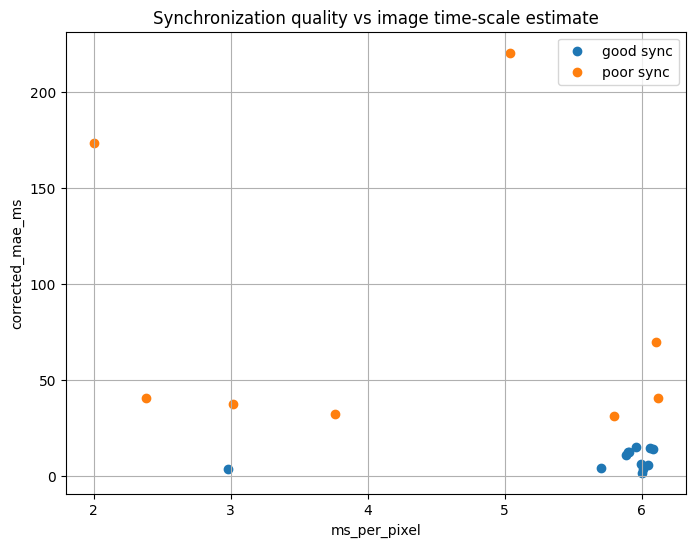

In [91]:
plt.figure(figsize=(8, 6))

good_mask = sync_gate_df["sync_quality"] == "good"

plt.scatter(
    sync_gate_df.loc[good_mask, "ms_per_pixel"],
    sync_gate_df.loc[good_mask, "corrected_mae_ms"],
    label="good sync",
)

plt.scatter(
    sync_gate_df.loc[~good_mask, "ms_per_pixel"],
    sync_gate_df.loc[~good_mask, "corrected_mae_ms"],
    label="poor sync",
)

plt.xlabel("ms_per_pixel")
plt.ylabel("corrected_mae_ms")
plt.title("Synchronization quality vs image time-scale estimate")

plt.legend()
plt.grid(True)

plt.show()